# Analyzer
Base reproducible para estudiar la evidencia de seguridad generada por el Miner.

**Pregunta general:** ¿Cómo se distribuyen los hallazgos de seguridad en la organización y qué patrones permiten identificar prioridades de revisión?

Los hallazgos son alertas o coincidencias, no vulnerabilidades confirmadas. Los análisis fallidos no representan ausencia de problemas.

## Preguntas de investigación

1. ¿Los hallazgos se concentran en pocos repositorios?
2. ¿Qué reglas de CodeQL son más frecuentes y cuáles se repiten entre proyectos?
3. ¿Cómo se distribuyen las severidades y los puntajes, y dónde se concentran los altos?
4. ¿Qué paquetes e identificadores de Grype son más frecuentes y cuáles se comparten?
5. ¿Existe relación entre los conteos de CodeQL y Grype entre repositorios con cobertura completa?
6. ¿En qué archivos se concentran los hallazgos de CodeQL dentro de cada repositorio?
7. ¿Qué ecosistemas predominan en el inventario de componentes y cómo varían entre repositorios?
8. ¿Qué repositorios tienen más componentes y qué proporción presenta coincidencias con vulnerabilidades conocidas?
9. ¿Qué componentes y versiones se comparten entre repositorios, tengan o no hallazgos?
10. ¿Qué problemas de seguridad se repiten en los workflows de CI y qué cobertura tiene su análisis?

Cada pregunta se desarrolla mediante método, resultados, interpretación y limitaciones.
No contar cada puntaje como un hallazgo nuevo.


## Preparación de los datos

Ejecuta las celdas en orden con el kernel de `analyzer/.venv`. La configuración localiza la raíz de `vulnerabilities` desde la carpeta actual o cualquiera de sus directorios superiores. Puedes abrir el notebook desde la raíz del repositorio o desde una subcarpeta.

Selecciona `ORGANIZATION`, `CLONE_RUN` y `SBOM_RUN` en la siguiente celda de configuración. Las entradas se cargan desde la evidencia versionada de `analyzer/data`; no dependen de las rutas absolutas originales del Miner.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


In [43]:
# Configuración de la evidencia dentro del repositorio unificado.
from pathlib import Path

current_directory = Path.cwd().resolve()
REPOSITORY_ROOT = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / 'miner/pyproject.toml').is_file()
        and (candidate / 'analyzer/notebooks/analyzer.ipynb').is_file()
    ),
    None,
)
if REPOSITORY_ROOT is None:
    raise FileNotFoundError(
        'No se encontró la raíz del repositorio con miner/ y analyzer/. '
        'Abre el notebook desde vulnerabilities o una de sus subcarpetas.'
    )

ANALYZER_ROOT = REPOSITORY_ROOT / 'analyzer'
ORGANIZATION = 'django'
CLONE_RUN = 'clone-x269596i'
SBOM_RUN = 'sbom-j7jbqezb'

# Evidencia versionada; su origen está en data/<organización>/provenance.json.
EVIDENCE_ROOT = ANALYZER_ROOT / 'data' / ORGANIZATION / CLONE_RUN
DATASET_PATH = EVIDENCE_ROOT / 'dataset.json'
SBOM_REPORT_PATH = EVIDENCE_ROOT / 'sboms' / SBOM_RUN / 'sbom-results.json'
for input_path in (DATASET_PATH, SBOM_REPORT_PATH):
    if not input_path.is_file():
        raise FileNotFoundError(
            f'Falta la entrada {input_path.relative_to(REPOSITORY_ROOT)}. '
            'Comprueba la ejecución seleccionada y los archivos de analyzer/data.'
        )
print(f'Dataset: {DATASET_PATH.relative_to(REPOSITORY_ROOT).as_posix()}')
print(f'Reporte SBOM: {SBOM_REPORT_PATH.relative_to(REPOSITORY_ROOT).as_posix()}')


Dataset: analyzer/data/django/clone-x269596i/dataset.json
Reporte SBOM: analyzer/data/django/clone-x269596i/sboms/sbom-j7jbqezb/sbom-results.json


In [44]:
with DATASET_PATH.open(encoding='utf-8') as dataset_file:
    dataset = json.load(dataset_file)

if not isinstance(dataset, dict):
    raise ValueError('El dataset debe ser un objeto JSON.')

supported_versions = {'1.0', '1.1'}
if dataset.get('schema_version') not in supported_versions:
    raise ValueError('Versión de dataset no compatible.')

for section in ('repositories', 'findings'):
    records = dataset.get(section)
    if not isinstance(records, list):
        raise ValueError(f'La sección {section} debe ser una lista.')
    if any(not isinstance(record, dict) for record in records):
        raise ValueError(f'La sección {section} contiene registros inválidos.')

repository_records = dataset['repositories']
finding_records = dataset['findings']
repository_names = {record['repository'] for record in repository_records}

for finding in finding_records:
    if finding.get('repository') not in repository_names:
        raise ValueError('Hay hallazgos de repositorios ausentes del dataset.')
    for field in ('tool', 'vulnerability_id'):
        if not isinstance(finding.get(field), str) or not finding[field].strip():
            raise ValueError(f'Un hallazgo no contiene un {field} válido.')

print(f"Organización: {dataset['organization']}")
print(f'Repositorios: {len(repository_records)}')
print(f'Hallazgos: {len(finding_records)}')



Organización: django
Repositorios: 31
Hallazgos: 202


In [45]:
repository_columns = [
    'repository',
    'clone_status',
    'codeql_status',
    'grype_status',
    'clone_error',
    'codeql_error',
    'grype_error',
]
finding_columns = [
    'repository',
    'tool',
    'vulnerability_id',
    'description',
    'severity',
    'severity_kind',
    'locations',
    'language',
    'package',
    'package_type',
    'version',
    'commit',
    'scores',
]
score_columns = [
    'finding_index',
    'repository',
    'tool',
    'value',
    'system',
    'source',
    'version',
    'vector',
    'vulnerability_id',
]

repositories = pd.DataFrame(repository_records).reindex(columns=repository_columns)
findings = pd.DataFrame(finding_records).reindex(columns=finding_columns)

score_rows = []
for finding_index, finding in enumerate(finding_records):
    for score in finding.get('scores', []):
        score_rows.append({
            **score,
            'finding_index': finding_index,
            'repository': finding['repository'],
            'tool': finding['tool'],
        })
scores = pd.DataFrame(score_rows).reindex(columns=score_columns)

display(repositories.head())
display(findings.head())
display(scores.head())



,repository,clone_status,codeql_status,grype_status,clone_error,codeql_error,grype_error
0,django/.github,cloned,database_failed,analyzed,None,CodeQL no pudo crear las bases de datos,None
1,django/accessibility,cloned,database_failed,analyzed,None,CodeQL no pudo crear las bases de datos,None
2,django/asgi_ipc,cloned,analyzed,analyzed,None,None,None
3,django/asgiref,cloned,analyzed,analyzed,None,None,None
4,django/birthday20,cloned,analyzed,analyzed,None,None,None


,repository,tool,vulnerability_id,description,severity,severity_kind,locations,language,package,package_type,version,commit,scores
0,django/code.djangoproject.com,grype,GHSA-p2m9-wcp5-6qw3,multipart vulnerable to ReDoS in `parse_option...,High,vulnerability_severity,[\requirements.txt],None,multipart,python,1.1.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 7.5, 'system': 'CVSS', 'source': 'h..."
1,django/code.djangoproject.com,grype,GHSA-v53h-f6m7-xcgm,Black's vulnerable version parsing leads to RC...,High,vulnerability_severity,[\.github\workflows\linters.yml],None,psf/black,github-action,25.9.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 8.7, 'system': 'CVSS', 'source': 'h..."
2,django/django,codeql,js/incomplete-url-substring-sanitization,'[earthdata.nasa.gov](1)' can be anywhere in t...,warning,sarif_level,[js_tests/gis/mapwidget.test.js],javascript,None,None,None,None,"[{'value': 7.8, 'system': 'security-severity',..."
3,django/django,codeql,py/bind-socket-all-network-interfaces,Binding a socket to all interfaces (using ['']...,error,sarif_level,[tests/servers/tests.py],python,None,None,None,None,"[{'value': 6.5, 'system': 'security-severity',..."
4,django/django,codeql,py/clear-text-logging-sensitive-data,This expression logs [sensitive data (password...,error,sarif_level,[django/db/backends/oracle/creation.py],python,None,None,None,None,"[{'value': 7.5, 'system': 'security-severity',..."


,finding_index,repository,tool,value,system,source,version,vector,vulnerability_id
0,0,django/code.djangoproject.com,grype,7.5,CVSS,https://github.com/advisories/GHSA-p2m9-wcp5-6qw3,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,GHSA-p2m9-wcp5-6qw3
1,0,django/code.djangoproject.com,grype,7.5,CVSS,0b0ca135-0b70-47e7-9f44-1890c2a1c46c,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,CVE-2026-28356
2,0,django/code.djangoproject.com,grype,7.5,CVSS,security-advisories@github.com,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,CVE-2026-28356
3,1,django/code.djangoproject.com,grype,8.7,CVSS,https://github.com/advisories/GHSA-v53h-f6m7-xcgm,4.0,CVSS:4.0/AV:N/AC:L/AT:N/PR:L/UI:N/VC:H/VI:H/VA...,GHSA-v53h-f6m7-xcgm
4,1,django/code.djangoproject.com,grype,9.8,CVSS,nvd@nist.gov,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,CVE-2026-31900


## Cobertura antes del análisis
Separar los estados por herramienta. `not_run`, fallos y análisis parciales deben considerarse al definir las poblaciones de comparación.

In [46]:
status_columns = ['clone_status', 'codeql_status', 'grype_status']
repository_stages = repositories.melt(
    id_vars='repository',
    value_vars=status_columns,
    var_name='stage',
    value_name='status',
)
coverage = (
    repository_stages.groupby(['stage', 'status'])
    .size()
    .rename('repositories')
    .reset_index()
)
findings_by_tool = (
    findings.groupby('tool')
    .size()
    .rename('findings')
    .reset_index()
)

display(coverage)
display(findings_by_tool)



,stage,status,repositories
0,clone_status,cloned,31
1,codeql_status,analyzed,19
2,codeql_status,database_failed,12
3,grype_status,analyzed,31


,tool,findings
0,codeql,69
1,grype,133


## Hallazgos repetidos por repositorio

Agrupamos por herramienta, identificador y repositorio. Coincidencias totales mide registros del Miner; repositorios afectados mide la extensión del hallazgo entre proyectos. Las reglas de CodeQL y los identificadores de Grype se mantienen separados. No se agrupa por puntaje ni se eliminan coincidencias de paquetes distintos.

In [47]:
frecuencias = (
    findings.groupby(['tool', 'vulnerability_id', 'repository'])
    .size()
    .rename('coincidencias')
    .reset_index()
    .sort_values(['tool', 'vulnerability_id', 'repository'])
)

repetidos = (
    frecuencias.groupby(['tool', 'vulnerability_id'])
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        coincidencias_totales=('coincidencias', 'sum'),
    )
    .reset_index()
    .sort_values(
        ['repositorios_afectados', 'coincidencias_totales', 'tool', 'vulnerability_id'],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

display(frecuencias, repetidos)

# Matriz de coincidencias: filas por hallazgo y columnas por repositorio.
matriz_hallazgos = frecuencias.pivot(
    index=['tool', 'vulnerability_id'], columns='repository', values='coincidencias'
).reindex(columns=sorted(repositories['repository'].unique())).fillna(0).astype(int)
display(matriz_hallazgos)
# Un cero solo indica ausencia de registros; consultar coverage para saber si hubo análisis.


,tool,vulnerability_id,repository,coincidencias
0,codeql,js/functionality-from-untrusted-source,django/django-asv,1
1,codeql,js/functionality-from-untrusted-source,django/djangobench,3
2,codeql,js/incomplete-url-substring-sanitization,django/django,1
3,codeql,js/xss-through-dom,django/djangopeople,1
4,codeql,py/bind-socket-all-network-interfaces,django/django,1
...,...,...,...,...
153,grype,GHSA-wvqv-fj8w-qmhm,django/djangosnippets.org,1
154,grype,GHSA-x78j-v8h9-3j2q,django/djangosnippets.org,1
155,grype,GHSA-x7m3-jprg-wc5g,django/djangopeople,1
156,grype,GHSA-xj96-63gp-2gmr,django/djangosnippets.org,1


,tool,vulnerability_id,repositorios_afectados,coincidencias_totales
0,codeql,py/url-redirection,4,20
1,codeql,py/weak-sensitive-data-hashing,3,4
2,grype,GHSA-gc5v-m9x4-r6x2,3,3
3,grype,GHSA-q238-5cxm-5c9h,3,3
4,codeql,js/functionality-from-untrusted-source,2,4
...,...,...,...,...
126,grype,GHSA-wjx4-4jcj-g98j,1,1
127,grype,GHSA-x78j-v8h9-3j2q,1,1
128,grype,GHSA-x7m3-jprg-wc5g,1,1
129,grype,GHSA-xj96-63gp-2gmr,1,1


repository                                       django/.github  \
tool   vulnerability_id                                           
codeql js/functionality-from-untrusted-source                 0   
       js/incomplete-url-substring-sanitization               0   
       js/xss-through-dom                                     0   
       py/bind-socket-all-network-interfaces                  0   
       py/clear-text-logging-sensitive-data                   0   
...                                                         ...   
grype  GHSA-wvqv-fj8w-qmhm                                    0   
       GHSA-x78j-v8h9-3j2q                                    0   
       GHSA-x7m3-jprg-wc5g                                    0   
       GHSA-xj96-63gp-2gmr                                    0   
       GHSA-xpv3-w29h-x7cv                                    0   

repository                                       django/accessibility  \
tool   vulnerability_id                                                 
codeql js/functionality-from-untrusted-source                       0   
       js/incomplete-url-substring-sanitization                     0   
       js/xss-through-dom                                           0   
       py/bind-socket-all-network-interfaces                        0   
       py/clear-text-logging-sensitive-data                         0   
...                                                               ...   
grype  GHSA-wvqv-fj8w-qmhm                                          0   
       GHSA-x78j-v8h9-3j2q                                          0   
       GHSA-x7m3-jprg-wc5g                                          0   
       GHSA-xj96-63gp-2gmr                                          0   
       GHSA-xpv3-w29h-x7cv                                          0   

repository                                       django/asgi_ipc  \
tool   vulnerability_id                                            
codeql js/functionality-from-untrusted-source                  0   
       js/incomplete-url-substring-sanitization                0   
       js/xss-through-dom                                      0   
       py/bind-socket-all-network-interfaces                   0   
       py/clear-text-logging-sensitive-data                    0   
...                                                          ...   
grype  GHSA-wvqv-fj8w-qmhm                                     0   
       GHSA-x78j-v8h9-3j2q                                     0   
       GHSA-x7m3-jprg-wc5g                                     0   
       GHSA-xj96-63gp-2gmr                                     0   
       GHSA-xpv3-w29h-x7cv                                     0   

repository                                       django/asgiref  \
tool   vulnerability_id                                           
codeql js/functionality-from-untrusted-source                 0   
       js/incomplete-url-substring-sanitization               0   
       js/xss-through-dom                                     0   
       py/bind-socket-all-network-interfaces                  0   
       py/clear-text-logging-sensitive-data                   0   
...                                                         ...   
grype  GHSA-wvqv-fj8w-qmhm                                    0   
       GHSA-x78j-v8h9-3j2q                                    0   
       GHSA-x7m3-jprg-wc5g                                    0   
       GHSA-xj96-63gp-2gmr                                    0   
       GHSA-xpv3-w29h-x7cv                                    0   

repository                                       django/birthday20  \
tool   vulnerability_id                                              
codeql js/functionality-from-untrusted-source                    0   
       js/incomplete-url-substring-sanitization                  0   
       js/xss-through-dom                                        0   
       py/bind-socket-all-network-interfaces                     0   
 

## Pregunta 1. ¿Los hallazgos se concentran en pocos repositorios?

### Método

Contar los registros por repositorio y herramienta y calcular su proporción dentro de cada herramienta.
Incluir todos los repositorios del dataset, conservando el estado del análisis. Un conteo cero no demuestra ausencia de problemas si el análisis falló.

### Resultados


In [48]:
conteos_por_repositorio = (
    findings.groupby(['repository', 'tool'])
    .size()
    .unstack('tool', fill_value=0)
    .reindex(
        index=repositories['repository'],
        columns=['codeql', 'grype'],
        fill_value=0,
    )
    .fillna(0)
    .astype(int)
)

concentracion = (
    conteos_por_repositorio
    .reset_index()
    .melt(
        id_vars='repository',
        var_name='tool',
        value_name='coincidencias',
    )
)
totales_por_herramienta = concentracion.groupby('tool')['coincidencias'].transform('sum')
concentracion['proporcion'] = (
    concentracion['coincidencias'] / totales_por_herramienta.replace(0, float('nan'))
)
concentracion = concentracion.sort_values(
    ['tool', 'coincidencias', 'repository'],
    ascending=[True, False, True],
)

estados_por_herramienta = repositories.melt(
    id_vars='repository',
    value_vars=['codeql_status', 'grype_status'],
    var_name='tool',
    value_name='status',
)
estados_por_herramienta['tool'] = (
    estados_por_herramienta['tool'].str.removesuffix('_status')
)
concentracion = concentracion.merge(
    estados_por_herramienta,
    on=['repository', 'tool'],
    validate='one_to_one',
)

display(concentracion)


,repository,tool,coincidencias,proporcion,status
0,django/django,codeql,52,0.753623,analyzed
1,django/djangoproject.com,codeql,6,0.086957,analyzed
2,django/djangopeople,codeql,5,0.072464,analyzed
3,django/djangobench,codeql,3,0.043478,analyzed
4,django/django-asv,codeql,1,0.014493,analyzed
...,...,...,...,...,...
57,django/dsf-minutes,grype,0,0.000000,analyzed
58,django/dsf-working-groups,grype,0,0.000000,analyzed
59,django/new-features,grype,0,0.000000,analyzed
60,django/online-community-working-group,grype,0,0.000000,analyzed


### Interpretación


In [49]:
observaciones_concentracion = []
for tool, group in concentracion.groupby('tool'):
    ordered = group.sort_values(['coincidencias', 'repository'], ascending=[False, True])
    positive = ordered.loc[ordered['coincidencias'] > 0]
    total = int(ordered['coincidencias'].sum())
    incomplete = int(ordered['status'].ne('analyzed').sum())
    if not total:
        observaciones_concentracion.append(
            f'- **{tool}** no contiene registros; {incomplete} repositorios no tienen análisis completo.'
        )
        continue
    leader = positive.iloc[0]
    top = positive.head(3)
    top_share = top['coincidencias'].sum() / total
    observaciones_concentracion.append(
        f'- **{tool}**: **{leader["repository"]}** reúne {int(leader["coincidencias"])} '
        f'de {total} registros ({leader["proporcion"]:.1%}). Los {len(top)} repositorios '
        f'principales concentran **{top_share:.1%}**; hay registros en '
        f'{len(positive)} de {len(ordered)} repositorios y {incomplete} análisis incompletos.'
    )
display(Markdown('\n'.join(observaciones_concentracion)))


- **codeql**: **django/django** reúne 52 de 69 registros (75.4%). Los 3 repositorios principales concentran **91.3%**; hay registros en 7 de 31 repositorios y 12 análisis incompletos.
- **grype**: **django/djangosnippets.org** reúne 91 de 133 registros (68.4%). Los 3 repositorios principales concentran **95.5%**; hay registros en 6 de 31 repositorios y 0 análisis incompletos.

### Limitaciones

Los conteos no están ajustados por tamaño del código ni número de dependencias. Se cuentan coincidencias, no vulnerabilidades únicas. La participación de los tres repositorios principales describe concentración observada, sin aplicar un umbral arbitrario para calificarla. Los fallos y la cobertura parcial condicionan la comparación.


## Pregunta 2. ¿Qué reglas de CodeQL son más frecuentes y cuáles se repiten entre proyectos?

### Método

Filtrar CodeQL y agrupar por identificador de regla. Una regla compartida aparece en al menos dos repositorios distintos. Distinguir el número de repositorios afectados del total de coincidencias: muchos casos en un solo proyecto no significan repetición entre proyectos.

### Resultados


In [50]:
reglas_compartidas = repetidos.loc[
    (repetidos['tool'] == 'codeql')
    & (repetidos['repositorios_afectados'] >= 2)
].copy()

repositorios_por_regla = frecuencias.loc[
    (frecuencias['tool'] == 'codeql')
    & frecuencias['vulnerability_id'].isin(reglas_compartidas['vulnerability_id'])
].copy()

display(reglas_compartidas)
display(repositorios_por_regla)


,tool,vulnerability_id,repositorios_afectados,coincidencias_totales
0,codeql,py/url-redirection,4,20
1,codeql,py/weak-sensitive-data-hashing,3,4
4,codeql,js/functionality-from-untrusted-source,2,4
5,codeql,py/stack-trace-exposure,2,3


,tool,vulnerability_id,repository,coincidencias
0,codeql,js/functionality-from-untrusted-source,django/django-asv,1
1,codeql,js/functionality-from-untrusted-source,django/djangobench,3
14,codeql,py/stack-trace-exposure,django/django,1
15,codeql,py/stack-trace-exposure,django/djangoproject.com,2
17,codeql,py/url-redirection,django/django,15
18,codeql,py/url-redirection,django/django-contrib-comments,1
19,codeql,py/url-redirection,django/djangopeople,2
20,codeql,py/url-redirection,django/djangoproject.com,2
21,codeql,py/weak-sensitive-data-hashing,django/django,1
22,codeql,py/weak-sensitive-data-hashing,django/djangopeople,2


### Frecuencia global y por repositorio

Se incluyen todas las reglas observadas, también las que aparecen en un único repositorio. El ranking global cuenta coincidencias; el ranking por repositorio presenta hasta cinco reglas, con desempate por identificador. Los mensajes de ejemplo proceden de la evidencia y ayudan a interpretar el tipo de alerta; no son una confirmación de vulnerabilidad.


In [51]:
codeql_todos = findings.loc[findings['tool'] == 'codeql']
reglas_globales = (
    codeql_todos.groupby('vulnerability_id')
    .agg(coincidencias=('repository', 'size'), repositorios=('repository', 'nunique'),
         ejemplo_mensaje=('description', 'first'))
    .reset_index()
    .sort_values(['coincidencias', 'vulnerability_id'], ascending=[False, True])
)
reglas_globales['proporcion'] = reglas_globales['coincidencias'] / (len(codeql_todos) or float('nan'))
reglas_por_repositorio = frecuencias.loc[frecuencias['tool'] == 'codeql'].copy()
reglas_por_repositorio['proporcion_en_repositorio'] = (
    reglas_por_repositorio['coincidencias']
    / reglas_por_repositorio.groupby('repository')['coincidencias'].transform('sum')
)
reglas_por_repositorio = reglas_por_repositorio.sort_values(
    ['repository', 'coincidencias', 'vulnerability_id'], ascending=[True, False, True],
)
top_reglas_por_repositorio = reglas_por_repositorio.groupby('repository', sort=False).head(5)
display(reglas_globales.round(3))
display(top_reglas_por_repositorio.round(3))


,vulnerability_id,coincidencias,repositorios,ejemplo_mensaje,proporcion
15,py/url-redirection,20,4,Untrusted URL redirection depends on a [user-p...,0.290
11,py/reflective-xss,16,1,Cross-site scripting vulnerability due to a [u...,0.232
9,py/path-injection,5,1,This path depends on a [user-provided value](1...,0.072
0,js/functionality-from-untrusted-source,4,2,Script loaded using unencrypted connection.,0.058
16,py/weak-sensitive-data-hashing,4,3,[Sensitive data (password)](1) is used in a ha...,0.058
7,py/full-ssrf,3,1,The full URL of this request depends on a [use...,0.043
13,py/stack-trace-exposure,3,2,[Stack trace information](1) flows to this loc...,0.043
5,py/clear-text-storage-sensitive-data,2,1,This expression stores [sensitive data (secret...,0.029
6,py/cookie-injection,2,1,Cookie is constructed from a [user-supplied in...,0.029
10,py/polynomial-redos,2,1,This [regular expression](1) that depends on a...,0.029


,tool,vulnerability_id,repository,coincidencias,proporcion_en_repositorio
12,codeql,py/reflective-xss,django/django,16,0.308
17,codeql,py/url-redirection,django/django,15,0.288
10,codeql,py/path-injection,django/django,5,0.096
8,codeql,py/full-ssrf,django/django,3,0.058
6,codeql,py/clear-text-storage-sensitive-data,django/django,2,0.038
0,codeql,js/functionality-from-untrusted-source,django/django-asv,1,1.000
18,codeql,py/url-redirection,django/django-contrib-comments,1,1.000
1,codeql,js/functionality-from-untrusted-source,django/djangobench,3,1.000
19,codeql,py/url-redirection,django/djangopeople,2,0.400
22,codeql,py/weak-sensitive-data-hashing,django/djangopeople,2,0.400


### Interpretación


In [52]:
observaciones_reglas = [
    f'- Se observaron **{len(reglas_globales)} reglas** de CodeQL; '
    f'**{len(reglas_compartidas)}** aparecen en al menos dos repositorios.',
]
if not reglas_globales.empty:
    main_rule = reglas_globales.iloc[0]
    observaciones_reglas.append(
        f'- La regla más frecuente es **{main_rule["vulnerability_id"]}**: '
        f'{int(main_rule["coincidencias"])} registros ({main_rule["proporcion"]:.1%}), '
        f'en {int(main_rule["repositorios"])} repositorios.'
    )
if not reglas_compartidas.empty:
    widest_rule = reglas_compartidas.sort_values(
        ['repositorios_afectados', 'coincidencias_totales', 'vulnerability_id'],
        ascending=[False, False, True],
    ).iloc[0]
    observaciones_reglas.append(
        f'- La regla más extendida es **{widest_rule["vulnerability_id"]}**, '
        f'presente en {int(widest_rule["repositorios_afectados"])} repositorios. '
        'Consultar sus mensajes de ejemplo en el ranking global para interpretar la alerta.'
    )
else:
    observaciones_reglas.append('- No hay reglas compartidas; esto no equivale a ausencia de alertas.')
display(Markdown('\n'.join(observaciones_reglas)))


- Se observaron **18 reglas** de CodeQL; **4** aparecen en al menos dos repositorios.
- La regla más frecuente es **py/url-redirection**: 20 registros (29.0%), en 4 repositorios.
- La regla más extendida es **py/url-redirection**, presente en 4 repositorios. Consultar sus mensajes de ejemplo en el ranking global para interpretar la alerta.

### Limitaciones

Compartir una regla significa compartir un tipo de alerta, no la misma vulnerabilidad concreta. La comparación depende de los lenguajes y repositorios analizados correctamente; no prueba que el problema sea explotable. Los identificadores y mensajes describen lo detectado por la herramienta, sin añadir explicaciones causales no verificadas. El ranking muestra frecuencia, no severidad ni riesgo.


## Pregunta 3. ¿Cómo se distribuyen las severidades y los puntajes, y dónde se concentran los altos?

### Introducción

Esta pregunta estudia la distribución de los hallazgos según los puntajes originales disponibles. Queremos distinguir los repositorios que acumulan muchos hallazgos con puntajes altos de aquellos donde estos representan una proporción importante de los hallazgos puntuados.

Las escalas de CodeQL y Grype se estudian por separado. Una puntuación alta orienta la revisión, pero no confirma la explotabilidad ni determina por sí sola el riesgo del repositorio.

### Método


#### CodeQL: puntaje de la regla

Usaremos el valor original `security-severity` que el Miner extrae de los metadatos de la regla en el SARIF. Es un valor entre **0,0 y 10,0** asociado a la regla o query que generó el hallazgo. GitHub clasifica sus valores como **Low** (0,1–3,9), **Medium** (4,0–6,9), **High** (7,0–8,9) y **Critical** (9,0–10,0). En el dataset se conserva en `scores`, con `system = "security-severity"` y `source = "codeql"`. El Analyzer utiliza `value` directamente: no consulta cada identificador ni convierte `warning`, `error` o `note` en números.

Para las consultas de seguridad incorporadas a las suites Default o Extended, GitHub documenta que el puntaje se asigna a la regla a partir del percentil 75 de los puntajes CVSS de CVE asociados a sus etiquetas CWE. Por ello, representa la severidad del tipo de problema detectado; no es una evaluación CVSS individual de cada ubicación de código ni demuestra su explotabilidad.

Fuente: [GitHub: cálculo de la severidad de seguridad](https://docs.github.com/en/code-security/concepts/code-scanning/code-scanning-alerts#calculation-of-security-severity-levels).

#### Grype: puntajes CVSS publicados

Usaremos los puntajes base que Grype proporciona en `scores`, con `system = "CVSS"`, conservando la fuente, versión, vector e identificador relacionado cuando estén disponibles. No se calcula una puntuación nueva a partir de la etiqueta cualitativa.

#### Decisiones metodológicas

- Se considera puntaje alto un valor mayor o igual a **7,0**.
- Cada hallazgo se cuenta una sola vez. Cuando contiene varios puntajes, se utiliza el máximo como valor representativo para priorización; las fuentes originales permanecen en `scores`.
- Una lista `scores` vacía significa que no hay puntuación disponible: no equivale a cero ni a severidad baja.
- CodeQL y Grype se resumen en filas separadas. Sus valores no se suman ni se promedian entre herramientas.
- La concentración se estudia mediante el número de hallazgos altos, su proporción entre los hallazgos puntuados y la cobertura de puntuación.


In [53]:
HIGH_SCORE_THRESHOLD = 7.0

if scores['value'].isna().any():
    raise ValueError('Hay puntajes sin valor numérico.')
if not scores['value'].between(0, 10).all():
    raise ValueError('Los puntajes deben estar entre 0 y 10.')

# Un valor representativo por hallazgo evita contar varias fuentes CVSS
# como si fueran vulnerabilidades distintas.
representative_scores = (
    scores.sort_values(
        ['finding_index', 'value', 'source'],
        ascending=[True, False, True],
        na_position='last',
    )
    .drop_duplicates('finding_index')
    .rename(columns={
        'value': 'representative_score',
        'system': 'score_system',
        'source': 'score_source',
        'version': 'score_version',
    })
)

scored_findings = (
    findings.reset_index(names='finding_index')
    .merge(
        representative_scores[
            [
                'finding_index',
                'representative_score',
                'score_system',
                'score_source',
                'score_version',
            ]
        ],
        on='finding_index',
        how='inner',
        validate='one_to_one',
    )
)
scored_findings['high_score'] = (
    scored_findings['representative_score'] >= HIGH_SCORE_THRESHOLD
)

display(scored_findings.head())

,finding_index,repository,tool,vulnerability_id,description,severity,severity_kind,locations,language,package,package_type,version,commit,scores,representative_score,score_system,score_source,score_version,high_score
0,0,django/code.djangoproject.com,grype,GHSA-p2m9-wcp5-6qw3,multipart vulnerable to ReDoS in `parse_option...,High,vulnerability_severity,[\requirements.txt],None,multipart,python,1.1.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 7.5, 'system': 'CVSS', 'source': 'h...",7.5,CVSS,0b0ca135-0b70-47e7-9f44-1890c2a1c46c,3.1,True
1,1,django/code.djangoproject.com,grype,GHSA-v53h-f6m7-xcgm,Black's vulnerable version parsing leads to RC...,High,vulnerability_severity,[\.github\workflows\linters.yml],None,psf/black,github-action,25.9.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 8.7, 'system': 'CVSS', 'source': 'h...",9.8,CVSS,nvd@nist.gov,3.1,True
2,2,django/django,codeql,js/incomplete-url-substring-sanitization,'[earthdata.nasa.gov](1)' can be anywhere in t...,warning,sarif_level,[js_tests/gis/mapwidget.test.js],javascript,None,None,None,None,"[{'value': 7.8, 'system': 'security-severity',...",7.8,security-severity,codeql,None,True
3,3,django/django,codeql,py/bind-socket-all-network-interfaces,Binding a socket to all interfaces (using ['']...,error,sarif_level,[tests/servers/tests.py],python,None,None,None,None,"[{'value': 6.5, 'system': 'security-severity',...",6.5,security-severity,codeql,None,False
4,4,django/django,codeql,py/clear-text-logging-sensitive-data,This expression logs [sensitive data (password...,error,sarif_level,[django/db/backends/oracle/creation.py],python,None,None,None,None,"[{'value': 7.5, 'system': 'security-severity',...",7.5,security-severity,codeql,None,True


### Resultados

La primera tabla resume la cobertura de puntuación por herramienta. La segunda compara los repositorios mediante cantidades absolutas y proporciones. `proporcion_altos` utiliza como denominador únicamente los hallazgos con puntaje; `proporcion_altos_herramienta` muestra qué fracción de todos los hallazgos altos de esa herramienta pertenece al repositorio.

In [54]:
hallazgos_por_herramienta = findings.groupby('tool').size().rename('hallazgos')
puntuados_por_herramienta = (
    scored_findings.groupby('tool').size().rename('hallazgos_puntuados')
)
altos_por_herramienta = (
    scored_findings.groupby('tool')['high_score'].sum().rename('hallazgos_altos')
)

cobertura_puntajes = (
    pd.concat(
        [hallazgos_por_herramienta, puntuados_por_herramienta, altos_por_herramienta],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
cobertura_puntajes['cobertura'] = (
    cobertura_puntajes['hallazgos_puntuados'] / cobertura_puntajes['hallazgos']
)
cobertura_puntajes['proporcion_altos'] = (
    cobertura_puntajes['hallazgos_altos']
    / cobertura_puntajes['hallazgos_puntuados'].replace(0, float('nan'))
)

base_repositorios = (
    findings.groupby(['repository', 'tool'])
    .size()
    .rename('hallazgos')
    .reset_index()
)
metricas_puntuadas = (
    scored_findings.groupby(['repository', 'tool'])
    .agg(
        hallazgos_puntuados=('finding_index', 'size'),
        hallazgos_altos=('high_score', 'sum'),
        puntaje_mediano=('representative_score', 'median'),
        puntaje_maximo=('representative_score', 'max'),
    )
    .reset_index()
)

metricas_pregunta_3 = (
    base_repositorios.merge(
        metricas_puntuadas,
        on=['repository', 'tool'],
        how='left',
        validate='one_to_one',
    )
    .fillna({'hallazgos_puntuados': 0, 'hallazgos_altos': 0})
)
metricas_pregunta_3[['hallazgos_puntuados', 'hallazgos_altos']] = (
    metricas_pregunta_3[['hallazgos_puntuados', 'hallazgos_altos']].astype(int)
)
metricas_pregunta_3['cobertura'] = (
    metricas_pregunta_3['hallazgos_puntuados'] / metricas_pregunta_3['hallazgos']
)
metricas_pregunta_3['proporcion_altos'] = (
    metricas_pregunta_3['hallazgos_altos']
    / metricas_pregunta_3['hallazgos_puntuados'].replace(0, float('nan'))
)
totales_altos = metricas_pregunta_3.groupby('tool')['hallazgos_altos'].transform('sum')
metricas_pregunta_3['proporcion_altos_herramienta'] = (
    metricas_pregunta_3['hallazgos_altos'] / totales_altos.replace(0, float('nan'))
)
metricas_pregunta_3 = metricas_pregunta_3.sort_values(
    ['tool', 'hallazgos_altos', 'proporcion_altos', 'repository'],
    ascending=[True, False, False, True],
).reset_index(drop=True)

display(cobertura_puntajes.round(3))
display(metricas_pregunta_3.round({
    'cobertura': 3,
    'proporcion_altos': 3,
    'proporcion_altos_herramienta': 3,
    'puntaje_mediano': 1,
    'puntaje_maximo': 1,
}))

,hallazgos,hallazgos_puntuados,hallazgos_altos,cobertura,proporcion_altos
tool,,,,,
codeql,69,69,39,1.0,0.565
grype,133,133,66,1.0,0.496


,repository,tool,hallazgos,hallazgos_puntuados,hallazgos_altos,puntaje_mediano,puntaje_maximo,cobertura,proporcion_altos,proporcion_altos_herramienta
0,django/django,codeql,52,52,33,7.5,9.3,1.0,0.635,0.846
1,django/djangopeople,codeql,5,5,3,7.5,7.8,1.0,0.600,0.077
2,django/djangoproject.com,codeql,6,6,2,6.1,7.8,1.0,0.333,0.051
3,django/djangosnippets.org,codeql,1,1,1,7.5,7.5,1.0,1.000,0.026
4,django/django-asv,codeql,1,1,0,6.0,6.0,1.0,0.000,0.000
5,django/django-contrib-comments,codeql,1,1,0,6.1,6.1,1.0,0.000,0.000
6,django/djangobench,codeql,3,3,0,6.0,6.0,1.0,0.000,0.000
7,django/djangosnippets.org,grype,91,91,45,6.9,9.8,1.0,0.495,0.682
8,django/djangopeople,grype,32,32,16,7.0,9.8,1.0,0.500,0.242
9,django/code.djangoproject.com,grype,2,2,2,8.6,9.8,1.0,1.000,0.030


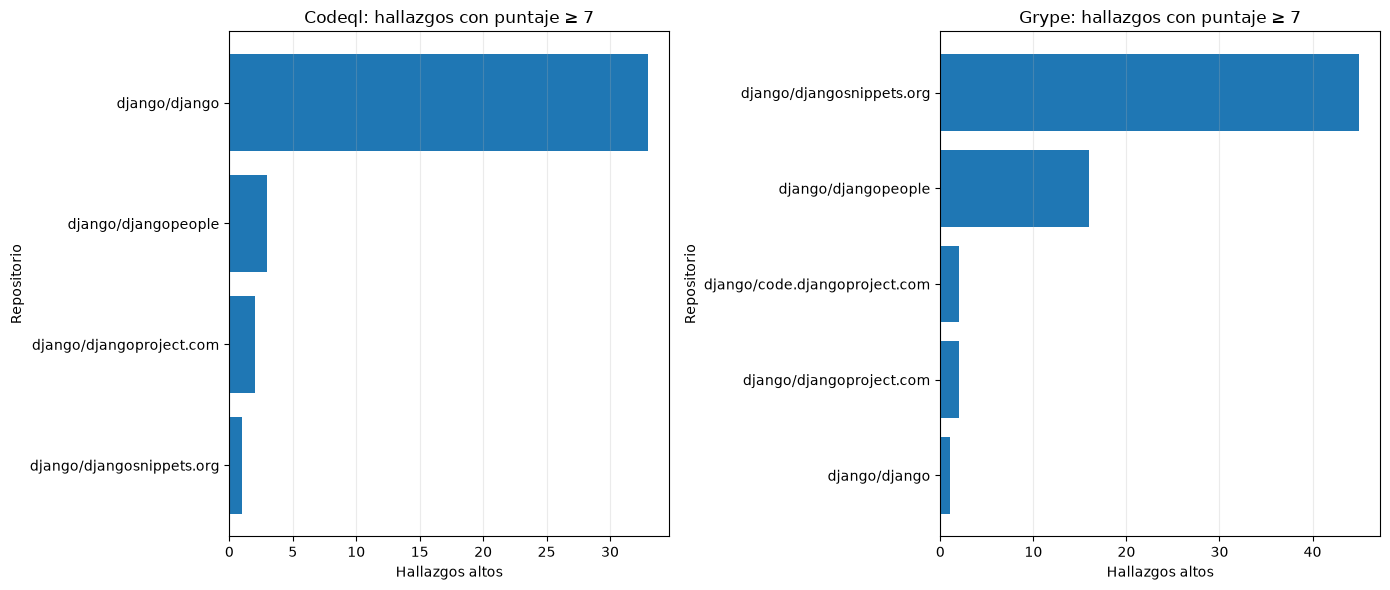

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for axis, tool in zip(axes, ['codeql', 'grype']):
    plot_data = metricas_pregunta_3.loc[
        (metricas_pregunta_3['tool'] == tool)
        & (metricas_pregunta_3['hallazgos_altos'] > 0)
    ].sort_values('hallazgos_altos')
    axis.barh(plot_data['repository'], plot_data['hallazgos_altos'])
    axis.set_title(f'{tool.capitalize()}: hallazgos con puntaje ≥ {HIGH_SCORE_THRESHOLD:g}')
    axis.set_xlabel('Hallazgos altos')
    axis.set_ylabel('Repositorio')
    axis.grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

### Distribución completa de severidades y puntajes

Las etiquetas se agrupan por herramienta y `severity_kind`; se conservan los valores ausentes como **Sin dato**. No se convierten etiquetas SARIF ni categorías de Grype en números.

Para los puntajes se utiliza el mismo máximo representativo por hallazgo definido antes. La tabla de frecuencias y los histogramas separan herramienta, sistema y versión del puntaje. Cada proporción usa el total puntuado de ese grupo. Los hallazgos sin puntaje permanecen en la tabla de cobertura y no se imputan como cero.


,tool,severity_kind,severity,hallazgos,proporcion
0,codeql,sarif_level,error,53,0.768
1,codeql,sarif_level,warning,16,0.232
2,grype,vulnerability_severity,Critical,6,0.045
3,grype,vulnerability_severity,High,51,0.383
4,grype,vulnerability_severity,Low,23,0.173
5,grype,vulnerability_severity,Medium,53,0.398


,tool,score_system,score_version,representative_score,hallazgos,proporcion
0,codeql,security-severity,No informada,5.0,2,0.029
1,codeql,security-severity,No informada,5.4,3,0.043
2,codeql,security-severity,No informada,6.0,4,0.058
3,codeql,security-severity,No informada,6.1,20,0.290
4,codeql,security-severity,No informada,6.5,1,0.014
5,codeql,security-severity,No informada,7.5,16,0.232
6,codeql,security-severity,No informada,7.8,19,0.275
7,codeql,security-severity,No informada,9.1,3,0.043
8,codeql,security-severity,No informada,9.3,1,0.014
9,grype,CVSS,3.0,7.5,2,0.667


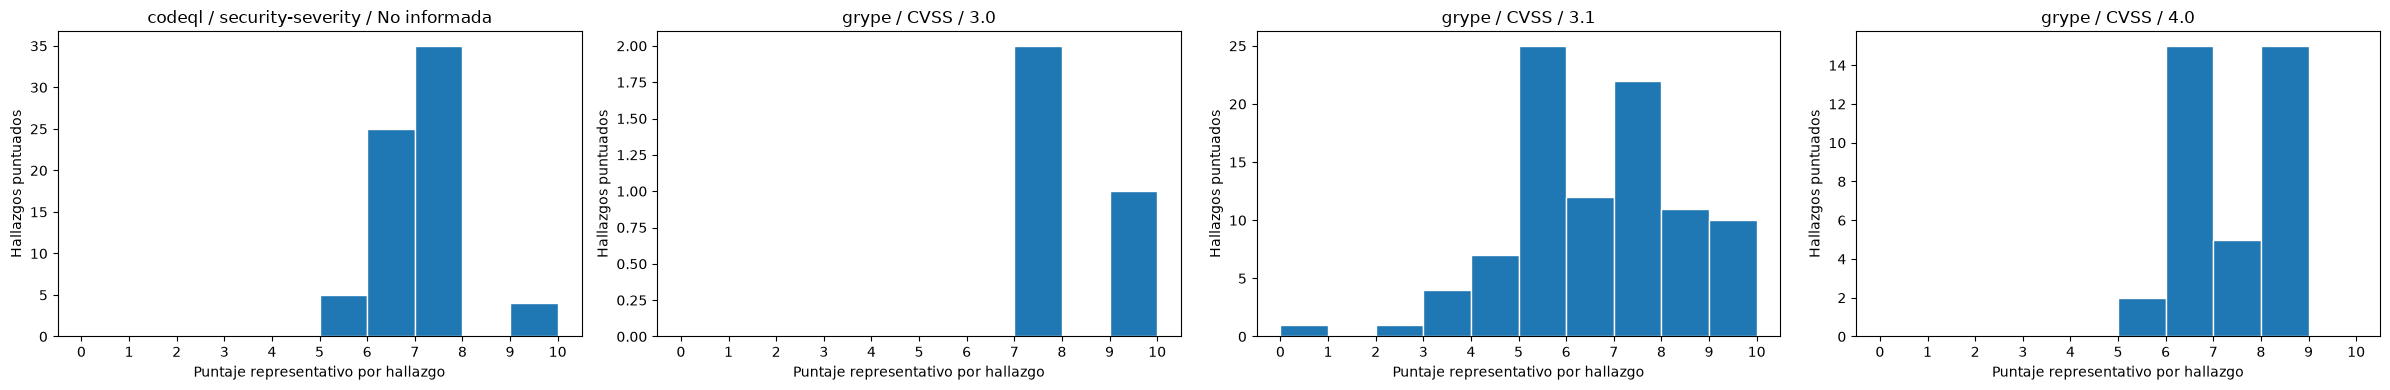

- **codeql / sarif_level**: la etiqueta más frecuente es **error**, con 53 registros (76.8%).
- **grype / vulnerability_severity**: la etiqueta más frecuente es **Medium**, con 53 registros (39.8%).

In [16]:
distribucion_severidades = (
    findings.assign(
        severity=findings['severity'].fillna('Sin dato'),
        severity_kind=findings['severity_kind'].fillna('Sin dato'),
    )
    .groupby(['tool', 'severity_kind', 'severity']).size().rename('hallazgos').reset_index()
)
distribucion_severidades['proporcion'] = (
    distribucion_severidades['hallazgos']
    / distribucion_severidades.groupby(['tool', 'severity_kind'])['hallazgos'].transform('sum')
)
puntajes_distribucion = scored_findings.assign(
    score_version=scored_findings['score_version'].fillna('No informada'),
    score_system=scored_findings['score_system'].fillna('No informado'),
)
grupos_puntaje = ['tool', 'score_system', 'score_version']
distribucion_puntajes = (
    puntajes_distribucion.groupby(grupos_puntaje + ['representative_score'])
    .size().rename('hallazgos').reset_index()
)
distribucion_puntajes['proporcion'] = (
    distribucion_puntajes['hallazgos']
    / distribucion_puntajes.groupby(grupos_puntaje)['hallazgos'].transform('sum')
)
display(distribucion_severidades.round(3))
display(distribucion_puntajes.round(3))

groups = list(puntajes_distribucion.groupby(grupos_puntaje))
if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4), squeeze=False)
    for axis, (group_key, data) in zip(axes.flat, groups):
        axis.hist(data['representative_score'], bins=list(range(11)), edgecolor='white')
        axis.set_title(' / '.join(map(str, group_key)))
        axis.set_xlabel('Puntaje representativo por hallazgo')
        axis.set_ylabel('Hallazgos puntuados')
        axis.set_xticks(range(11))
    fig.tight_layout()
    plt.show()
else:
    print('No hay puntajes disponibles para representar su distribución.')

observaciones_distribucion = []
for (tool, kind), group in distribucion_severidades.groupby(['tool', 'severity_kind']):
    leader = group.sort_values(['hallazgos', 'severity'], ascending=[False, True]).iloc[0]
    observaciones_distribucion.append(
        f'- **{tool} / {kind}**: la etiqueta más frecuente es **{leader["severity"]}**, '
        f'con {leader["hallazgos"]} registros ({leader["proporcion"]:.1%}).'
    )
display(Markdown('\n'.join(observaciones_distribucion)))


### Interpretación

In [17]:
observaciones = []
for tool in ['codeql', 'grype']:
    tool_metrics = metricas_pregunta_3.loc[
        (metricas_pregunta_3['tool'] == tool)
        & (metricas_pregunta_3['hallazgos_altos'] > 0)
    ]
    if tool_metrics.empty:
        observaciones.append(
            f'- **{tool.capitalize()}** no registró hallazgos puntuados sobre el umbral.'
        )
        continue

    leader = tool_metrics.iloc[0]
    observations_share = leader['proporcion_altos_herramienta']
    observaciones.append(
        f"- **{tool.capitalize()}** concentra su mayor cantidad en "
        f"**{leader['repository']}**, con {leader['hallazgos_altos']} hallazgos altos "
        f"({observations_share:.1%} del total alto de la herramienta)."
    )

display(Markdown(
    '\n'.join(observaciones)
    + '\n\nLos conteos absolutos muestran concentración operativa; las proporciones '
      'indican intensidad entre los hallazgos que sí tienen puntaje. Un repositorio '
      'puede destacar en una medida y no en la otra, por lo que ambas deben '
      'consultarse junto con la cobertura.'
))

- **Codeql** concentra su mayor cantidad en **django/django**, con 33 hallazgos altos (84.6% del total alto de la herramienta).
- **Grype** concentra su mayor cantidad en **django/djangosnippets.org**, con 45 hallazgos altos (68.2% del total alto de la herramienta).

Los conteos absolutos muestran concentración operativa; las proporciones indican intensidad entre los hallazgos que sí tienen puntaje. Un repositorio puede destacar en una medida y no en la otra, por lo que ambas deben consultarse junto con la cobertura.

### Limitaciones

Los puntajes de CodeQL pertenecen a las reglas; los CVSS de Grype provienen de vulnerabilidades conocidas. El máximo elegido entre varias fuentes sirve para priorizar y puede ser conservador, pero no sustituye una evaluación de riesgo. No se combinan las herramientas en una única escala ni se infieren valores ausentes. La cobertura del análisis, las versiones CVSS y el tamaño de los proyectos condicionan las conclusiones.

## Pregunta 4. ¿Qué paquetes e identificadores de Grype son más frecuentes y cuáles se comparten?

### Método

Se filtran los hallazgos de Grype y se estudian dos agrupaciones complementarias:

1. **Vulnerabilidades compartidas:** un identificador aparece en al menos dos repositorios distintos.
2. **Paquetes compartidos:** un paquete vulnerable aparece en al menos dos repositorios distintos.

`repositorios_afectados` mide la extensión dentro de la organización. `coincidencias_totales` conserva el número de registros producidos por el Miner. Las versiones y ubicaciones se mantienen para interpretar si los repositorios comparten realmente la misma dependencia afectada.

In [18]:
grype_findings = findings.loc[findings['tool'] == 'grype'].copy()

if grype_findings.empty:
    raise ValueError('El dataset no contiene hallazgos de Grype.')

vulnerabilidades_grype = (
    grype_findings.groupby('vulnerability_id')
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        coincidencias_totales=('repository', 'size'),
        paquetes_afectados=('package', 'nunique'),
        severidades=('severity', lambda values: sorted(values.dropna().unique())),
    )
    .reset_index()
)

vulnerabilidades_compartidas = (
    vulnerabilidades_grype.loc[
        vulnerabilidades_grype['repositorios_afectados'] >= 2
    ]
    .sort_values(
        ['repositorios_afectados', 'coincidencias_totales', 'vulnerability_id'],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

detalle_vulnerabilidades_compartidas = (
    grype_findings.loc[
        grype_findings['vulnerability_id'].isin(
            vulnerabilidades_compartidas['vulnerability_id']
        ),
        ['vulnerability_id', 'repository', 'package', 'version', 'severity', 'locations'],
    ]
    .sort_values(['vulnerability_id', 'repository', 'package', 'version'])
    .reset_index(drop=True)
)

display(vulnerabilidades_compartidas)
display(detalle_vulnerabilidades_compartidas.head(20))

,vulnerability_id,repositorios_afectados,coincidencias_totales,paquetes_afectados,severidades
0,GHSA-gc5v-m9x4-r6x2,3,3,1,[Medium]
1,GHSA-q238-5cxm-5c9h,3,3,1,[Medium]
2,GHSA-3h9f-r86x-qvjx,2,2,1,[Low]
3,GHSA-8988-9cw3-xx77,2,2,1,[High]
4,GHSA-8cjm-8mp7-r2xf,2,2,1,[Low]
5,GHSA-8qcx-xf44-272x,2,2,1,[Medium]
6,GHSA-923m-gv2p-w5qp,2,2,1,[Low]
7,GHSA-9hjg-9r4m-mvj7,2,2,1,[Medium]
8,GHSA-9wx4-h78v-vm56,2,2,1,[Medium]
9,GHSA-crhf-3pfg-w68w,2,2,1,[Medium]


,vulnerability_id,repository,package,version,severity,locations
0,GHSA-3h9f-r86x-qvjx,django/djangopeople,django,2.1.10,Low,[\requirements.txt]
1,GHSA-3h9f-r86x-qvjx,django/djangosnippets.org,django,5.2.7,Low,[\uv.lock]
2,GHSA-8988-9cw3-xx77,django/djangoproject.com,urllib3,2.7.0,High,[\uv.lock]
3,GHSA-8988-9cw3-xx77,django/djangosnippets.org,urllib3,2.5.0,High,[\uv.lock]
4,GHSA-8cjm-8mp7-r2xf,django/djangopeople,django,2.1.10,Low,[\requirements.txt]
5,GHSA-8cjm-8mp7-r2xf,django/djangosnippets.org,django,5.2.7,Low,[\uv.lock]
6,GHSA-8qcx-xf44-272x,django/djangopeople,django,2.1.10,Medium,[\requirements.txt]
7,GHSA-8qcx-xf44-272x,django/djangosnippets.org,django,5.2.7,Medium,[\uv.lock]
8,GHSA-923m-gv2p-w5qp,django/djangopeople,django,2.1.10,Low,[\requirements.txt]
9,GHSA-923m-gv2p-w5qp,django/djangosnippets.org,django,5.2.7,Low,[\uv.lock]


In [19]:
paquetes_grype = (
    grype_findings.dropna(subset=['package'])
    .groupby(['package', 'package_type'], dropna=False)
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        vulnerabilidades_distintas=('vulnerability_id', 'nunique'),
        coincidencias_totales=('repository', 'size'),
        versiones_observadas=('version', lambda values: sorted(values.dropna().unique())),
    )
    .reset_index()
)

paquetes_compartidos = (
    paquetes_grype.loc[paquetes_grype['repositorios_afectados'] >= 2]
    .sort_values(
        [
            'repositorios_afectados',
            'vulnerabilidades_distintas',
            'coincidencias_totales',
            'package',
        ],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

detalle_paquetes_compartidos = (
    grype_findings.merge(
        paquetes_compartidos[['package', 'package_type']],
        on=['package', 'package_type'], how='inner', validate='many_to_one',
    )[['package', 'package_type', 'repository', 'version', 'vulnerability_id', 'severity']]
    .sort_values(['package', 'package_type', 'repository', 'version', 'vulnerability_id'])
    .reset_index(drop=True)
)

display(paquetes_compartidos)
display(detalle_paquetes_compartidos.head(20))

,package,package_type,repositorios_afectados,vulnerabilidades_distintas,coincidencias_totales,versiones_observadas
0,django,python,3,42,53,"[2.1.10, 5.2.7, 6.1]"
1,requests,python,3,4,8,"[2.22.0, 2.31.0, 2.32.4]"
2,urllib3,python,2,7,9,"[2.5.0, 2.7.0]"
3,gunicorn,python,2,2,4,"[19.9.0, 20.1.0]"
4,psf/black,github-action,2,1,2,"[25.9.0, stable]"


,package,package_type,repository,version,vulnerability_id,severity
0,django,python,django/djangopeople,2.1.10,GHSA-3h9f-r86x-qvjx,Low
1,django,python,django/djangopeople,2.1.10,GHSA-68w8-qjq3-2gfm,Medium
2,django,python,django/djangopeople,2.1.10,GHSA-6r97-cj55-9hrq,Critical
3,django,python,django/djangopeople,2.1.10,GHSA-6w2r-r2m5-xq5w,High
4,django,python,django/djangopeople,2.1.10,GHSA-7xr5-9hcq-chf9,Medium
5,django,python,django/djangopeople,2.1.10,GHSA-8cjm-8mp7-r2xf,Low
6,django,python,django/djangopeople,2.1.10,GHSA-8qcx-xf44-272x,Medium
7,django,python,django/djangopeople,2.1.10,GHSA-8x94-hmjh-97hq,High
8,django,python,django/djangopeople,2.1.10,GHSA-923m-gv2p-w5qp,Low
9,django,python,django/djangopeople,2.1.10,GHSA-c4qh-4vgv-qc6g,High


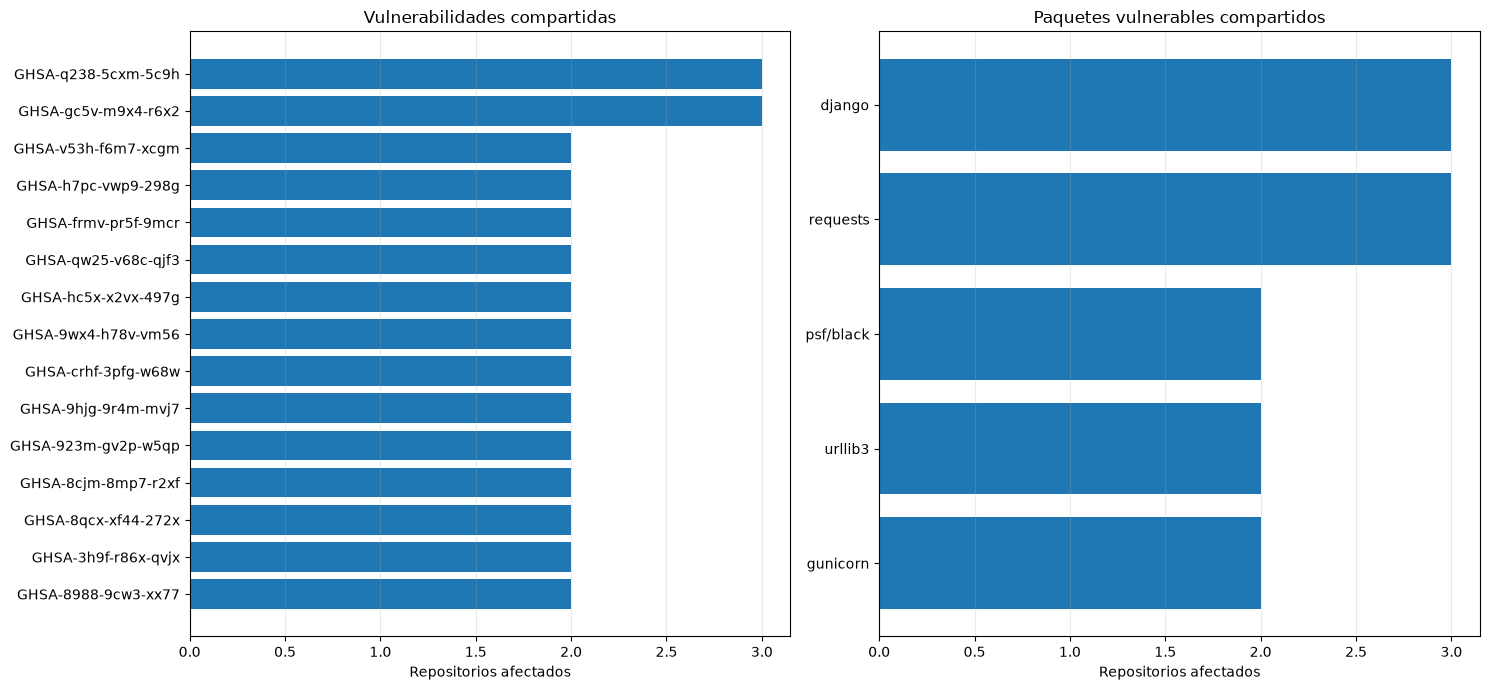

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_vulnerabilidades = vulnerabilidades_compartidas.head(15).sort_values(
    'repositorios_afectados'
)
axes[0].barh(
    top_vulnerabilidades['vulnerability_id'],
    top_vulnerabilidades['repositorios_afectados'],
)
axes[0].set_title('Vulnerabilidades compartidas')
axes[0].set_xlabel('Repositorios afectados')
axes[0].grid(axis='x', alpha=0.25)

top_paquetes = paquetes_compartidos.head(15).sort_values('repositorios_afectados')
axes[1].barh(
    top_paquetes['package'],
    top_paquetes['repositorios_afectados'],
)
axes[1].set_title('Paquetes vulnerables compartidos')
axes[1].set_xlabel('Repositorios afectados')
axes[1].grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

### Paquetes e identificadores más frecuentes

Estos rankings incluyen los registros de un único repositorio. Los paquetes se distinguen por nombre y tipo de ecosistema. Para cada uno se presentan tanto coincidencias totales como identificadores distintos; esas medidas no son intercambiables. Los identificadores CVE/GHSA se mantienen como aparecen en la evidencia, sin resolver posibles alias.


,package,package_type,repositorios_afectados,vulnerabilidades_distintas,coincidencias_totales,versiones_observadas
0,django,python,3,42,53,"[2.1.10, 5.2.7, 6.1]"
1,pillow,python,1,19,19,[12.0.0]
2,urllib3,python,2,7,9,"[2.5.0, 2.7.0]"
3,requests,python,3,4,8,"[2.22.0, 2.31.0, 2.32.4]"
4,sqlparse,python,1,6,6,[0.5.3]
5,virtualenv,python,1,5,5,[20.35.4]
6,gunicorn,python,2,2,4,"[19.9.0, 20.1.0]"
7,django-allauth,python,1,3,3,[65.9.0]
8,werkzeug,python,1,3,3,[3.1.3]
9,bleach,python,1,2,2,[6.2.0]


,vulnerability_id,repositorios_afectados,coincidencias_totales,paquetes_afectados,severidades
0,GHSA-gc5v-m9x4-r6x2,3,3,1,[Medium]
1,GHSA-q238-5cxm-5c9h,3,3,1,[Medium]
2,GHSA-3h9f-r86x-qvjx,2,2,1,[Low]
3,GHSA-8988-9cw3-xx77,2,2,1,[High]
4,GHSA-8cjm-8mp7-r2xf,2,2,1,[Low]
...,...,...,...,...,...
108,GHSA-wjx4-4jcj-g98j,1,1,1,[Medium]
109,GHSA-x78j-v8h9-3j2q,1,1,1,[High]
110,GHSA-x7m3-jprg-wc5g,1,1,1,[Critical]
111,GHSA-xj96-63gp-2gmr,1,1,1,[High]


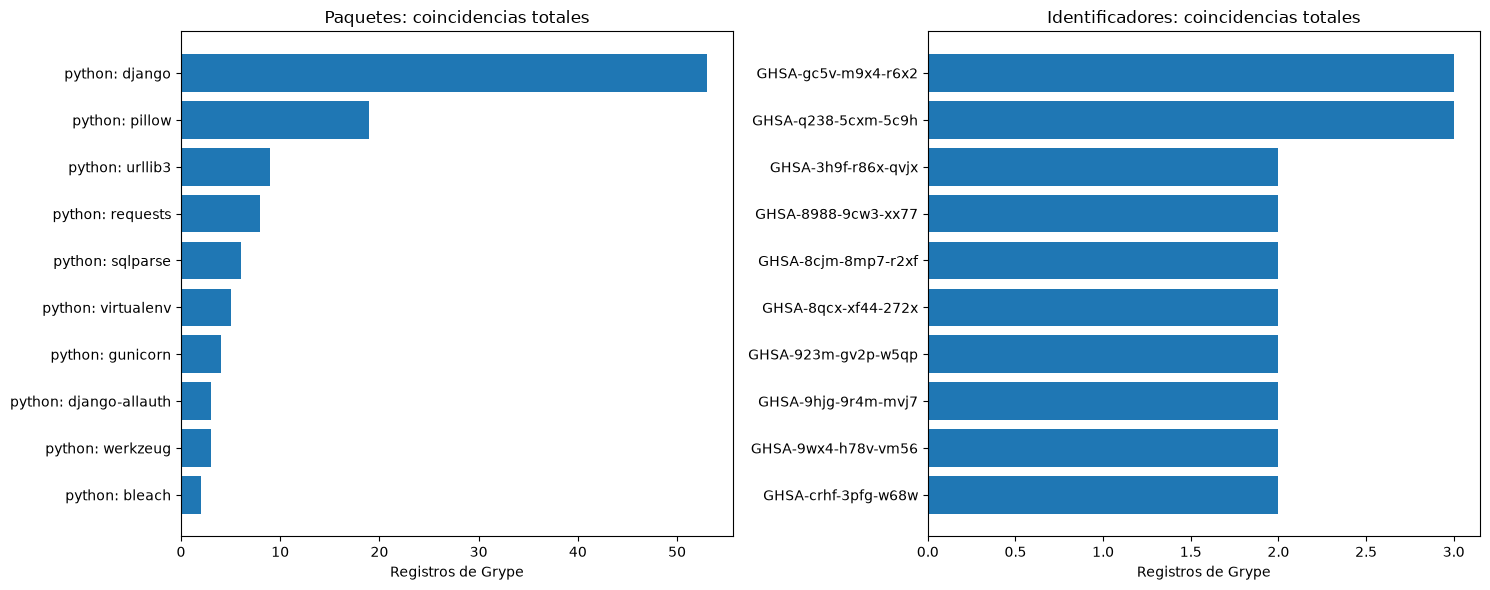

- **django (python)** acumula 53 coincidencias y 42 identificadores distintos, en 3 repositorios.
- **GHSA-gc5v-m9x4-r6x2** es el identificador con más coincidencias: 3 en 3 repositorios.

In [21]:
ranking_paquetes_grype = paquetes_grype.sort_values(
    ['coincidencias_totales', 'vulnerabilidades_distintas', 'package_type', 'package'],
    ascending=[False, False, True, True],
).reset_index(drop=True)
ranking_identificadores_grype = vulnerabilidades_grype.sort_values(
    ['coincidencias_totales', 'repositorios_afectados', 'vulnerability_id'],
    ascending=[False, False, True],
).reset_index(drop=True)
display(ranking_paquetes_grype)
display(ranking_identificadores_grype)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, frame, label, title in [
    (axes[0], ranking_paquetes_grype, 'package', 'Paquetes: coincidencias totales'),
    (axes[1], ranking_identificadores_grype, 'vulnerability_id', 'Identificadores: coincidencias totales'),
]:
    top = frame.head(10).iloc[::-1]
    labels = (top['package_type'].fillna('Sin tipo') + ': ' + top[label]) if label == 'package' else top[label]
    axis.barh(labels, top['coincidencias_totales'])
    axis.set_title(title)
    axis.set_xlabel('Registros de Grype')
fig.tight_layout()
plt.show()

observaciones_ranking_grype = []
if not ranking_paquetes_grype.empty:
    first_package = ranking_paquetes_grype.iloc[0]
    observaciones_ranking_grype.append(
        f'- **{first_package["package"]} ({first_package["package_type"]})** acumula '
        f'{int(first_package["coincidencias_totales"])} coincidencias y '
        f'{int(first_package["vulnerabilidades_distintas"])} identificadores distintos, '
        f'en {int(first_package["repositorios_afectados"])} repositorios.'
    )
if not ranking_identificadores_grype.empty:
    first_id = ranking_identificadores_grype.iloc[0]
    observaciones_ranking_grype.append(
        f'- **{first_id["vulnerability_id"]}** es el identificador con más coincidencias: '
        f'{int(first_id["coincidencias_totales"])} en {int(first_id["repositorios_afectados"])} repositorios.'
    )
display(Markdown('\n'.join(observaciones_ranking_grype)))


### Interpretación

In [22]:
observaciones_pregunta_4 = [
    f'- Se encontraron **{len(vulnerabilidades_compartidas)} vulnerabilidades** '
    'presentes en al menos dos repositorios.',
    f'- Se encontraron **{len(paquetes_compartidos)} paquetes vulnerables** '
    'presentes en al menos dos repositorios.',
]

if not vulnerabilidades_compartidas.empty:
    lider_vulnerabilidad = vulnerabilidades_compartidas.iloc[0]
    observaciones_pregunta_4.append(
        f"- La vulnerabilidad más extendida es "
        f"**{lider_vulnerabilidad['vulnerability_id']}**, presente en "
        f"**{lider_vulnerabilidad['repositorios_afectados']} repositorios**."
    )

if not paquetes_compartidos.empty:
    lider_paquete = paquetes_compartidos.iloc[0]
    observaciones_pregunta_4.append(
        f"- El paquete vulnerable más extendido es **{lider_paquete['package']}**, "
        f"presente en **{lider_paquete['repositorios_afectados']} repositorios** "
        f"y relacionado con **{lider_paquete['vulnerabilidades_distintas']} "
        "identificadores distintos**."
    )

display(Markdown(
    '\n'.join(observaciones_pregunta_4)
    + '\n\nLa repetición sugiere dependencias comunes que pueden revisarse de manera '
      'coordinada. Antes de priorizar una actualización debe consultarse el detalle '
      'de versiones, porque compartir el nombre del paquete no implica usar la misma '
      'versión ni tener la misma exposición.'
))

- Se encontraron **18 vulnerabilidades** presentes en al menos dos repositorios.
- Se encontraron **5 paquetes vulnerables** presentes en al menos dos repositorios.
- La vulnerabilidad más extendida es **GHSA-gc5v-m9x4-r6x2**, presente en **3 repositorios**.
- El paquete vulnerable más extendido es **django**, presente en **3 repositorios** y relacionado con **42 identificadores distintos**.

La repetición sugiere dependencias comunes que pueden revisarse de manera coordinada. Antes de priorizar una actualización debe consultarse el detalle de versiones, porque compartir el nombre del paquete no implica usar la misma versión ni tener la misma exposición.

### Limitaciones

Grype analiza componentes declarados en los SBOM y los contrasta con bases de vulnerabilidades conocidas. Una coincidencia no demuestra que el código vulnerable sea alcanzable durante la ejecución. Un mismo paquete puede aparecer con versiones distintas, y un identificador puede relacionarse con más de una fuente o paquete. Los resultados dependen de la completitud del SBOM y del estado de la base de datos de Grype al momento del análisis.

## Pregunta 5. ¿Existe relación entre los conteos de CodeQL y Grype?

### Introducción

Esta pregunta estudia si los repositorios con más hallazgos de código también tienden a presentar más vulnerabilidades conocidas en sus dependencias. Solo se incluyen repositorios cuyo estado sea `analyzed` tanto en CodeQL como en Grype; así, un análisis fallido no se interpreta como un conteo igual a cero.

### Método: correlación de Spearman

La correlación de Spearman mide si dos variables mantienen una relación **monotónica**: cuando una aumenta, la otra tiende a aumentar o disminuir, aunque la relación no sea lineal. En lugar de comparar directamente los conteos, el método realiza estos pasos:

1. Ordena los repositorios según sus hallazgos de CodeQL y asigna un rango a cada uno.
2. Repite el proceso con los hallazgos de Grype.
3. Cuando varios repositorios empatan, les asigna el rango promedio de las posiciones que ocupan.
4. Calcula la correlación de Pearson entre ambas columnas de rangos.

El coeficiente resultante, **rho de Spearman (`ρ`)**, está entre `-1` y `1`:

- `ρ` cercano a `1`: los repositorios con más hallazgos de CodeQL tienden a tener más hallazgos de Grype.
- `ρ` cercano a `-1`: los repositorios con más hallazgos de una herramienta tienden a tener menos de la otra.
- `ρ` cercano a `0`: no se observa una relación monotónica clara.

Se usa Spearman porque los conteos tienen muchos empates y valores extremos, y no se puede asumir una distribución normal ni una relación lineal. El cálculo se realiza directamente con los rangos para no incorporar una dependencia adicional.

In [23]:
repositorios_cobertura_completa = repositories.loc[
    (repositories['codeql_status'] == 'analyzed')
    & (repositories['grype_status'] == 'analyzed'),
    ['repository', 'codeql_status', 'grype_status'],
]

conteos_relacion = (
    conteos_por_repositorio.reset_index()
    .merge(
        repositorios_cobertura_completa,
        on='repository',
        how='inner',
        validate='one_to_one',
    )
    .rename(columns={'codeql': 'hallazgos_codeql', 'grype': 'hallazgos_grype'})
)

if len(conteos_relacion) < 2:
    raise ValueError('Se necesitan al menos dos repositorios con cobertura completa.')
if (
    conteos_relacion['hallazgos_codeql'].nunique() < 2
    or conteos_relacion['hallazgos_grype'].nunique() < 2
):
    raise ValueError('Los conteos no tienen variación suficiente para calcular Spearman.')

conteos_relacion['rango_codeql'] = conteos_relacion['hallazgos_codeql'].rank(
    method='average'
)
conteos_relacion['rango_grype'] = conteos_relacion['hallazgos_grype'].rank(
    method='average'
)
rho_spearman = conteos_relacion['rango_codeql'].corr(
    conteos_relacion['rango_grype']
)

conteos_relacion = conteos_relacion.sort_values(
    ['hallazgos_codeql', 'hallazgos_grype', 'repository'],
    ascending=[False, False, True],
).reset_index(drop=True)

print(f'Repositorios incluidos: {len(conteos_relacion)}')
print(f'Rho de Spearman: {rho_spearman:.3f}')
display(conteos_relacion)

Repositorios incluidos: 19
Rho de Spearman: 0.513


,repository,hallazgos_codeql,hallazgos_grype,codeql_status,grype_status,rango_codeql,rango_grype
0,django/django,52,1,analyzed,analyzed,19.0,14.0
1,django/djangoproject.com,6,4,analyzed,analyzed,18.0,17.0
2,django/djangopeople,5,32,analyzed,analyzed,17.0,18.0
3,django/djangobench,3,0,analyzed,analyzed,16.0,7.0
4,django/djangosnippets.org,1,91,analyzed,analyzed,14.0,19.0
5,django/django-asv,1,0,analyzed,analyzed,14.0,7.0
6,django/django-contrib-comments,1,0,analyzed,analyzed,14.0,7.0
7,django/ticketbot,0,3,analyzed,analyzed,6.5,16.0
8,django/code.djangoproject.com,0,2,analyzed,analyzed,6.5,15.0
9,django/asgi_ipc,0,0,analyzed,analyzed,6.5,7.0


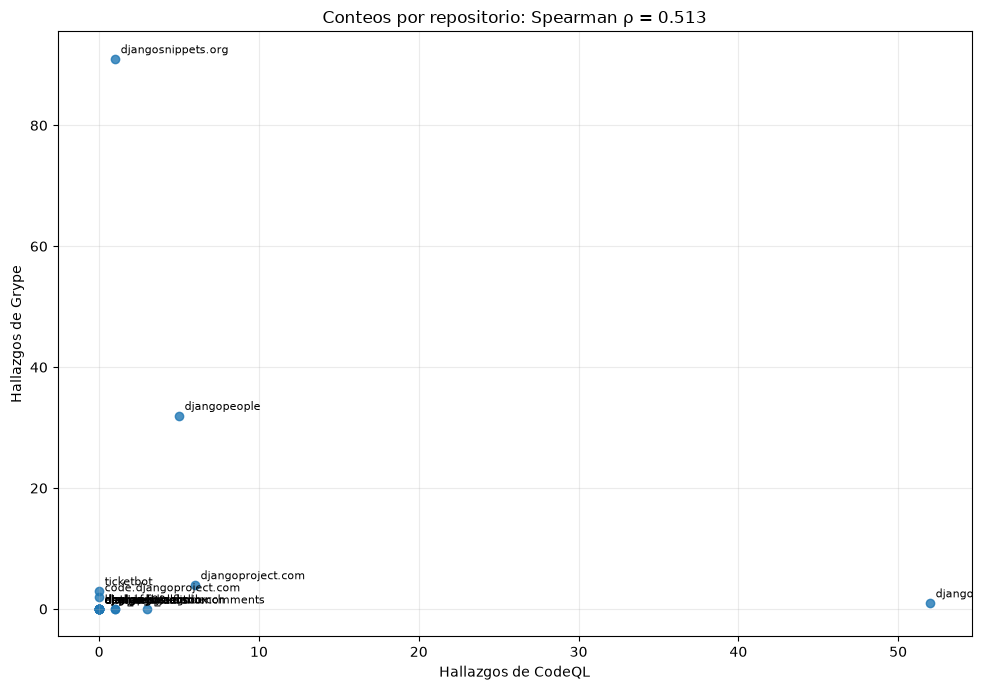

In [24]:
fig, axis = plt.subplots(figsize=(10, 7))
axis.scatter(
    conteos_relacion['hallazgos_codeql'],
    conteos_relacion['hallazgos_grype'],
    alpha=0.8,
)

for row in conteos_relacion.itertuples():
    axis.annotate(
        row.repository.removeprefix(f"{dataset['organization']}/"),
        (row.hallazgos_codeql, row.hallazgos_grype),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

axis.set_title(f'Conteos por repositorio: Spearman ρ = {rho_spearman:.3f}')
axis.set_xlabel('Hallazgos de CodeQL')
axis.set_ylabel('Hallazgos de Grype')
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Interpretación

In [25]:
magnitud = abs(rho_spearman)
if magnitud >= 0.7:
    intensidad = 'fuerte'
elif magnitud >= 0.4:
    intensidad = 'moderada'
elif magnitud >= 0.2:
    intensidad = 'débil'
else:
    intensidad = 'muy débil'

if rho_spearman > 0:
    direccion = 'positiva'
elif rho_spearman < 0:
    direccion = 'negativa'
else:
    direccion = 'nula'

display(Markdown(
    f'Entre los **{len(conteos_relacion)} repositorios** con cobertura completa, '
    f'el coeficiente es **ρ = {rho_spearman:.3f}**, lo que describe una relación '
    f'**{direccion} y {intensidad}** entre los rangos de hallazgos de CodeQL y Grype. '
    'Esta clasificación resume la magnitud observada y no constituye por sí sola '
    'una prueba de significancia estadística.'
))

Entre los **19 repositorios** con cobertura completa, el coeficiente es **ρ = 0.513**, lo que describe una relación **positiva y moderada** entre los rangos de hallazgos de CodeQL y Grype. Esta clasificación resume la magnitud observada y no constituye por sí sola una prueba de significancia estadística.

### Limitaciones

La correlación describe asociación, no causalidad: los hallazgos de código no producen necesariamente vulnerabilidades en dependencias. Los conteos no están normalizados por líneas de código, cantidad de dependencias ni tamaño del repositorio. La muestra es pequeña y contiene empates y valores extremos; por ello se informan el coeficiente, el gráfico y el número de repositorios incluidos, sin afirmar significancia estadística. CodeQL y Grype además observan dimensiones de seguridad diferentes.

## Pregunta 6. ¿En qué archivos se concentran los hallazgos de CodeQL dentro de cada repositorio?

### Método

Se estudian los hallazgos de CodeQL y sus rutas en `locations`. Cada registro del dataset recibe un `finding_index`; si menciona varias veces el mismo archivo, se cuenta una sola vez en ese archivo. Si menciona archivos distintos, contribuye una vez a cada uno.

Se presentan los tres archivos con más hallazgos por repositorio, el número de reglas distintas y la proporción respecto de todos los hallazgos de CodeQL del repositorio. Los empates se resuelven por ruta alfabética para obtener un máximo de tres archivos reproducible.

La concentración conjunta del top 3 usa la **unión de hallazgos** asociados a esos archivos: un hallazgo presente en dos archivos del top se cuenta una sola vez. Las proporciones individuales por archivo no deben sumarse.

Se informa además la cobertura de ubicación y el estado de CodeQL para todos los repositorios. Los repositorios sin hallazgos tienen proporciones no definidas; un fallo de análisis no se interpreta como ausencia de problemas.


In [26]:
codeql_archivos = (
    findings.loc[findings['tool'] == 'codeql']
    .reset_index(names='finding_index')
    .copy()
)

def rutas_unicas(locations):
    if not isinstance(locations, list):
        return []
    return sorted({
        location.strip().replace('\\', '/')
        for location in locations
        if isinstance(location, str) and location.strip()
    })

codeql_archivos['archivos'] = codeql_archivos['locations'].map(rutas_unicas)
ubicaciones_codeql = (
    codeql_archivos[['finding_index', 'repository', 'vulnerability_id', 'archivos']]
    .explode('archivos')
    .rename(columns={'archivos': 'archivo'})
    .dropna(subset=['archivo'])
    .drop_duplicates(['finding_index', 'archivo'])
)

resumen_archivos = (
    repositories[['repository', 'codeql_status']]
    .merge(
        codeql_archivos.groupby('repository').size().rename('hallazgos_codeql'),
        on='repository', how='left', validate='one_to_one',
    )
    .merge(
        ubicaciones_codeql.groupby('repository').agg(
            hallazgos_con_ubicacion=('finding_index', 'nunique'),
            archivos_con_hallazgos=('archivo', 'nunique'),
        ),
        on='repository', how='left', validate='one_to_one',
    )
)
columnas_conteo = ['hallazgos_codeql', 'hallazgos_con_ubicacion', 'archivos_con_hallazgos']
resumen_archivos[columnas_conteo] = resumen_archivos[columnas_conteo].fillna(0).astype(int)
resumen_archivos['hallazgos_sin_ubicacion'] = (
    resumen_archivos['hallazgos_codeql'] - resumen_archivos['hallazgos_con_ubicacion']
)
resumen_archivos['cobertura_ubicacion'] = (
    resumen_archivos['hallazgos_con_ubicacion']
    / resumen_archivos['hallazgos_codeql'].replace(0, float('nan'))
)

hallazgos_por_archivo = (
    ubicaciones_codeql.groupby(['repository', 'archivo'])
    .agg(
        hallazgos=('finding_index', 'nunique'),
        reglas_distintas=('vulnerability_id', 'nunique'),
    )
    .reset_index()
    .merge(
        resumen_archivos[['repository', 'codeql_status', 'hallazgos_codeql']],
        on='repository', how='left', validate='many_to_one',
    )
)
hallazgos_por_archivo['proporcion_del_repositorio'] = (
    hallazgos_por_archivo['hallazgos'] / hallazgos_por_archivo['hallazgos_codeql']
)
hallazgos_por_archivo = hallazgos_por_archivo.sort_values(
    ['repository', 'hallazgos', 'archivo'], ascending=[True, False, True],
).reset_index(drop=True)
top_archivos = hallazgos_por_archivo.groupby('repository', sort=False).head(3).copy()

hallazgos_top_3 = (
    ubicaciones_codeql.merge(
        top_archivos[['repository', 'archivo']],
        on=['repository', 'archivo'], how='inner', validate='many_to_one',
    )
    .groupby('repository')['finding_index'].nunique()
    .rename('hallazgos_en_top_3')
)
resumen_archivos = resumen_archivos.merge(
    hallazgos_top_3, on='repository', how='left', validate='one_to_one',
)
resumen_archivos['hallazgos_en_top_3'] = resumen_archivos['hallazgos_en_top_3'].fillna(0).astype(int)
resumen_archivos['proporcion_top_3'] = (
    resumen_archivos['hallazgos_en_top_3']
    / resumen_archivos['hallazgos_codeql'].replace(0, float('nan'))
)
resumen_archivos = resumen_archivos.sort_values(
    ['hallazgos_codeql', 'repository'], ascending=[False, True],
).reset_index(drop=True)

display(resumen_archivos.round(3))
display(top_archivos.round({'proporcion_del_repositorio': 3}))


,repository,codeql_status,hallazgos_codeql,hallazgos_con_ubicacion,archivos_con_hallazgos,hallazgos_sin_ubicacion,cobertura_ubicacion,hallazgos_en_top_3,proporcion_top_3
0,django/django,analyzed,52,52,24,0,1.0,15,0.288
1,django/djangoproject.com,analyzed,6,6,4,0,1.0,5,0.833
2,django/djangopeople,analyzed,5,5,4,0,1.0,4,0.800
3,django/djangobench,analyzed,3,3,3,0,1.0,3,1.000
4,django/django-asv,analyzed,1,1,1,0,1.0,1,1.000
5,django/django-contrib-comments,analyzed,1,1,1,0,1.0,1,1.000
6,django/djangosnippets.org,analyzed,1,1,1,0,1.0,1,1.000
7,django/.github,database_failed,0,0,0,0,NaN,0,NaN
8,django/accessibility,database_failed,0,0,0,0,NaN,0,NaN
9,django/asgi_ipc,analyzed,0,0,0,0,NaN,0,NaN


,repository,archivo,hallazgos,reglas_distintas,codeql_status,hallazgos_codeql,proporcion_del_repositorio
0,django/django,tests/test_client_regress/views.py,7,2,analyzed,52,0.135
1,django/django,django/contrib/auth/views.py,4,1,analyzed,52,0.077
2,django/django,django/views/static.py,4,1,analyzed,52,0.077
24,django/django-asv,benchmarks/template_benchmarks/template_render...,1,1,analyzed,1,1.000
25,django/django-contrib-comments,django_comments/views/utils.py,1,1,analyzed,1,1.000
26,django/djangobench,djangobench/benchmarks/template_render/templat...,1,1,analyzed,3,0.333
27,django/djangobench,djangobench/benchmarks/template_render/templat...,1,1,analyzed,3,0.333
28,django/djangobench,djangobench/benchmarks/template_render/templat...,1,1,analyzed,3,0.333
29,django/djangopeople,djangopeople/django_openidconsumer/views.py,2,1,analyzed,5,0.400
30,django/djangopeople,djangopeople/django_openidauth/views.py,1,1,analyzed,5,0.200


### Resultados

Cada panel muestra los archivos principales de un repositorio. Las etiquetas indican el conteo y su porcentaje respecto de los hallazgos de CodeQL de ese repositorio. Las escalas horizontales son independientes; la tabla anterior permite comparar cantidades exactas y consultar la cobertura.


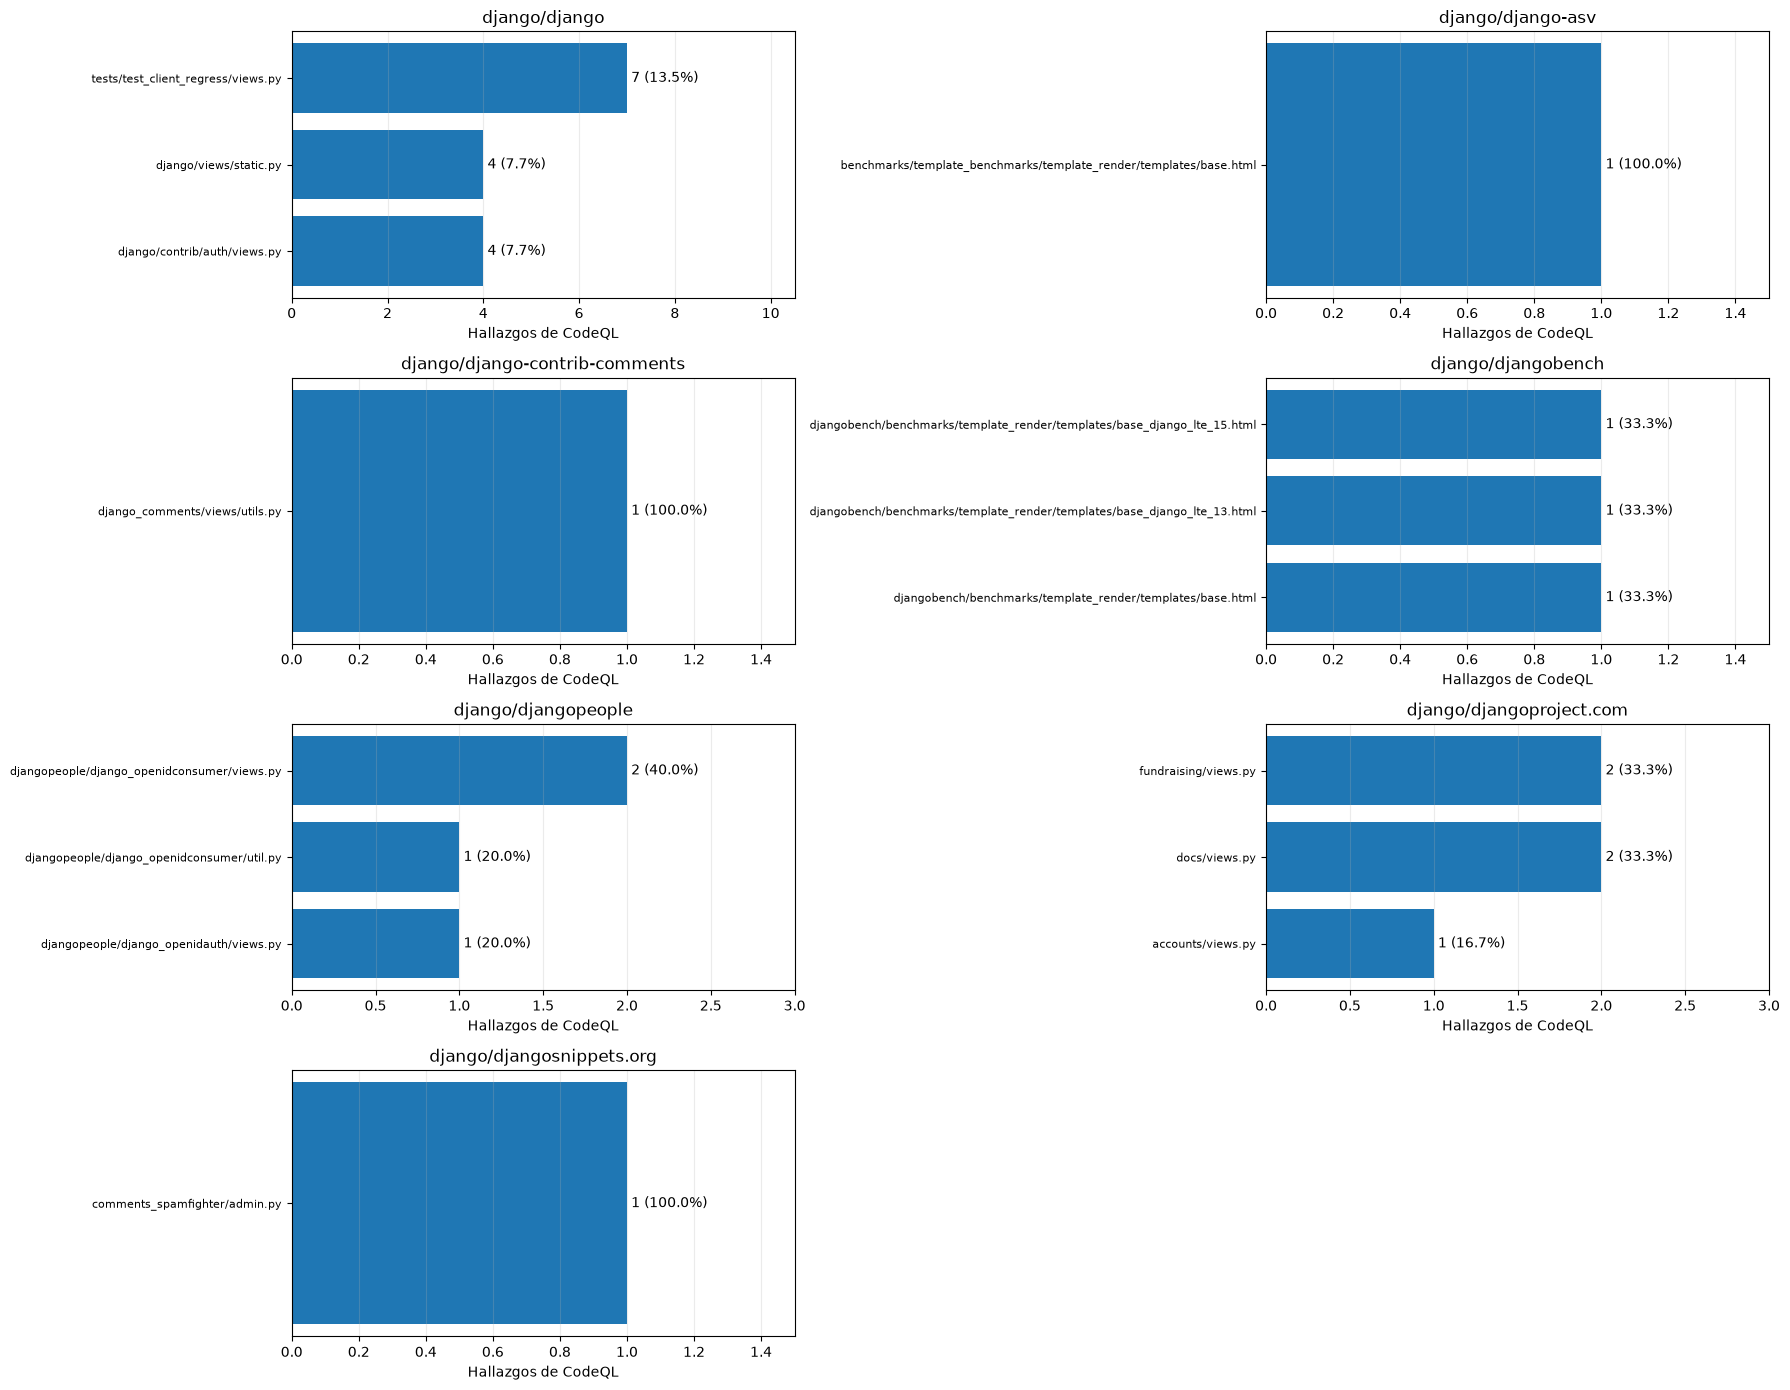

In [27]:
repositorios_con_archivos = top_archivos['repository'].drop_duplicates().tolist()
if not repositorios_con_archivos:
    print('No hay hallazgos de CodeQL con rutas de archivo disponibles.')
else:
    filas = (len(repositorios_con_archivos) + 1) // 2
    fig, axes = plt.subplots(filas, 2, figsize=(18, 3.5 * filas), squeeze=False)
    for axis, repository in zip(axes.flat, repositorios_con_archivos):
        datos_archivo = top_archivos.loc[
            top_archivos['repository'] == repository
        ].sort_values(['hallazgos', 'archivo'])
        barras = axis.barh(datos_archivo['archivo'], datos_archivo['hallazgos'])
        axis.bar_label(barras, labels=[
            f'{row.hallazgos} ({row.proporcion_del_repositorio:.1%})'
            for row in datos_archivo.itertuples()
        ], padding=3)
        axis.set_xlim(0, datos_archivo['hallazgos'].max() * 1.5)
        axis.set_title(repository)
        axis.set_xlabel('Hallazgos de CodeQL')
        axis.tick_params(axis='y', labelsize=8)
        axis.grid(axis='x', alpha=0.25)
    for axis in list(axes.flat)[len(repositorios_con_archivos):]:
        axis.set_visible(False)
    fig.tight_layout()
    plt.show()


### Interpretación


In [28]:
observaciones_archivos = []
for row in resumen_archivos.itertuples():
    if row.hallazgos_codeql == 0:
        continue
    if row.hallazgos_con_ubicacion == 0:
        observaciones_archivos.append(
            f'- **{row.repository}**: {row.hallazgos_codeql} hallazgos sin ruta; '
            'no se puede calcular su concentración por archivo.'
        )
        continue
    cantidad_archivos = int((top_archivos['repository'] == row.repository).sum())
    observaciones_archivos.append(
        f'- **{row.repository}**: los {cantidad_archivos} archivos principales '
        f'reúnen {row.hallazgos_en_top_3} de {row.hallazgos_codeql} hallazgos '
        f'({row.proporcion_top_3:.1%}); cobertura de ubicación '
        f'{row.cobertura_ubicacion:.1%}, estado `{row.codeql_status}`.'
    )

sin_analisis_completo = int((resumen_archivos['codeql_status'] != 'analyzed').sum())
observaciones_archivos.append(
    f'- **{sin_analisis_completo} repositorios** tienen un estado de CodeQL '
    'distinto de `analyzed`; sus conteos no representan una revisión completa.'
)
display(Markdown('\n'.join(observaciones_archivos)))


- **django/django**: los 3 archivos principales reúnen 15 de 52 hallazgos (28.8%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/djangoproject.com**: los 3 archivos principales reúnen 5 de 6 hallazgos (83.3%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/djangopeople**: los 3 archivos principales reúnen 4 de 5 hallazgos (80.0%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/djangobench**: los 3 archivos principales reúnen 3 de 3 hallazgos (100.0%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/django-asv**: los 1 archivos principales reúnen 1 de 1 hallazgos (100.0%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/django-contrib-comments**: los 1 archivos principales reúnen 1 de 1 hallazgos (100.0%); cobertura de ubicación 100.0%, estado `analyzed`.
- **django/djangosnippets.org**: los 1 archivos principales reúnen 1 de 1 hallazgos (100.0%); cobertura de ubicación 100.0%, estado `analyzed`.
- **12 repositorios** tienen un estado de CodeQL distinto de `analyzed`; sus conteos no representan una revisión completa.

### Limitaciones

Se cuentan alertas de CodeQL, no vulnerabilidades confirmadas. Las rutas proceden de las ubicaciones conservadas por el Miner; no representan necesariamente todo el recorrido del flujo de datos de una alerta.

La concentración no está normalizada por líneas de código ni tamaño del archivo. Un porcentaje alto puede corresponder a muy pocos hallazgos o a un repositorio pequeño. Se incluyen archivos de pruebas y ejemplos: su contexto debe revisarse antes de priorizar. Los análisis fallidos o parciales y las ubicaciones ausentes limitan las conclusiones.


## Pregunta 7. ¿Qué ecosistemas predominan en el inventario de componentes y cómo varían entre repositorios?

### Método

Se utiliza el inventario CycloneDX completo de la ejecución seleccionada en `SBOM_REPORT_PATH`, incluidos componentes sin coincidencias de Grype. El reporte `sbom-results.json` identifica cada repositorio, su estado y el archivo que corresponde cargar. Las rutas originales se resuelven por nombre de archivo dentro de la copia local de esa ejecución.

La unidad de conteo es cada registro de `components`, coherente con `component_count` del Miner. Se cuentan apariciones en los inventarios: un paquete repetido en distintos repositorios contribuye a cada uno. No se interpreta este total como paquetes únicos ni como dependencias directas.

Para clasificar el ecosistema se utiliza `syft:package:type`: `python` se presenta como **PyPI**, `npm` como **npm** y los tipos `github-action` y `github-action-workflow` como **GitHub Actions**. Si falta ese dato, se usa el tipo de PURL (`pypi`, `npm`, etc.); un PURL `github` sin el tipo de Syft se mantiene como **GitHub (PURL)**, sin asumir que sea una acción. Los demás tipos se conservan identificados por su fuente y los componentes sin clasificación se agrupan como **Sin clasificar**. El campo CycloneDX `type` (por ejemplo, `library`) no se usa como ecosistema.

Se calculan cantidades, proporciones y repositorios con presencia de cada ecosistema. La distribución por repositorio usa como denominador sus componentes inventariados. Un SBOM válido sin componentes se muestra como vacío, con proporciones no definidas; fallos, archivos ausentes y documentos inválidos se muestran aparte y no cuentan como inventarios vacíos.


In [29]:
def ecosistema_componente(component):
    properties = component.get('properties', [])
    syft_type = next((
        item.get('value') for item in properties
        if isinstance(item, dict) and item.get('name') == 'syft:package:type'
        and isinstance(item.get('value'), str) and item['value'].strip()
    ), None) if isinstance(properties, list) else None
    if syft_type:
        syft_type = syft_type.strip().lower()
        label = {'python': 'PyPI', 'npm': 'npm', 'github-action': 'GitHub Actions', 'github-action-workflow': 'GitHub Actions'}.get(
            syft_type, f'Syft: {syft_type}',
        )
        return label, 'syft:package:type'
    purl = component.get('purl')
    if isinstance(purl, str) and purl.startswith('pkg:') and '/' in purl[4:]:
        purl_type = purl[4:].split('/', 1)[0].lower()
        if purl_type:
            label = {'pypi': 'PyPI', 'npm': 'npm', 'github': 'GitHub (PURL)'}.get(
                purl_type, f'PURL: {purl_type}',
            )
            return label, 'purl'
    return 'Sin clasificar', 'sin_dato'


def cargar_inventario_sbom(report_path, organization, repository_names):
    with report_path.open(encoding='utf-8') as report_file:
        report = json.load(report_file)
    if not isinstance(report, dict) or report.get('organization') != organization:
        raise ValueError('El reporte SBOM no corresponde a la organización seleccionada.')
    records = report.get('repositories')
    if not isinstance(records, list):
        raise ValueError('El reporte SBOM debe contener una lista de repositorios.')

    coverage_rows, component_rows, seen = [], [], set()
    for record in records:
        if not isinstance(record, dict):
            raise ValueError('Registro inválido en el reporte SBOM.')
        repository = record.get('full_name')
        if repository not in repository_names or repository in seen:
            raise ValueError(f'Repositorio desconocido o repetido en SBOM: {repository}')
        seen.add(repository)
        row = {
            'repository': repository,
            'sbom_status': record.get('status'),
            'componentes_reportados': record.get('component_count'),
            'componentes_cargados': None,
            'sbom_vacio': None,
            'error': record.get('error'),
        }
        if row['sbom_status'] not in {'generated', 'failed'}:
            raise ValueError(f'Estado SBOM no reconocido: {row["sbom_status"]}')
        if row['sbom_status'] == 'generated':
            try:
                # Usa únicamente un archivo de la copia local, nunca la ruta original.
                stored_path = record.get('sbom_path')
                if not isinstance(stored_path, str) or not stored_path.strip():
                    raise ValueError('El reporte no contiene una ruta de SBOM.')
                filename = stored_path.replace('\\', '/').rsplit('/', 1)[-1]
                local_path = report_path.parent / filename
                with local_path.open(encoding='utf-8') as sbom_file:
                    document = json.load(sbom_file)
                if not isinstance(document, dict) or document.get('bomFormat') != 'CycloneDX':
                    raise ValueError('El archivo no es un documento CycloneDX.')
                components = document.get('components', [])
                if not isinstance(components, list) or any(not isinstance(c, dict) for c in components):
                    raise ValueError('La lista de componentes es inválida.')
                if len(components) != record.get('component_count'):
                    raise ValueError('El número de componentes difiere del reporte del Miner.')
            except FileNotFoundError as error:
                row.update(sbom_status='missing', error=str(error))
            except (OSError, ValueError) as error:
                row.update(sbom_status='invalid', error=str(error))
            else:
                row.update(componentes_cargados=len(components), sbom_vacio=not components)
                for index, component in enumerate(components):
                    ecosystem, classification_source = ecosistema_componente(component)
                    component_rows.append({
                        'repository': repository,
                        'component_index': index,
                        'name': component.get('name'),
                        'version': component.get('version'),
                        'purl': component.get('purl'),
                        'ecosistema': ecosystem,
                        'fuente_clasificacion': classification_source,
                    })
        coverage_rows.append(row)
    for repository in sorted(repository_names - seen):
        coverage_rows.append({
            'repository': repository, 'sbom_status': 'not_reported',
            'componentes_reportados': None, 'componentes_cargados': None,
            'sbom_vacio': None, 'error': 'Repositorio ausente del reporte SBOM.',
        })
    coverage_df = pd.DataFrame(coverage_rows, columns=[
        'repository', 'sbom_status', 'componentes_reportados',
        'componentes_cargados', 'sbom_vacio', 'error',
    ]).sort_values('repository').reset_index(drop=True)
    components_df = pd.DataFrame(component_rows, columns=[
        'repository', 'component_index', 'name', 'version', 'purl',
        'ecosistema', 'fuente_clasificacion',
    ])
    return coverage_df, components_df


cobertura_sbom, componentes_sbom = cargar_inventario_sbom(
    SBOM_REPORT_PATH, dataset['organization'], set(repositories['repository']),
)
display(cobertura_sbom)
display(cobertura_sbom.groupby('sbom_status').size().rename('repositorios').to_frame())


,repository,sbom_status,componentes_reportados,componentes_cargados,sbom_vacio,error
0,django/.github,generated,0,0,True,None
1,django/accessibility,generated,0,0,True,None
2,django/asgi_ipc,generated,0,0,True,None
3,django/asgiref,generated,2,2,False,None
4,django/birthday20,generated,10,10,False,None
5,django/channels,generated,4,4,False,None
6,django/channels_redis,generated,2,2,False,None
7,django/code-of-conduct,generated,2,2,False,None
8,django/code.djangoproject.com,generated,18,18,False,None
9,django/daphne,generated,2,2,False,None


,repositorios
sbom_status,
generated,31


### Resultados

La primera tabla presenta la composición global y el número de repositorios en los que aparece cada ecosistema. `proporcion_repositorios` usa todos los SBOM válidos cargados, incluidos los vacíos. La segunda tabla muestra cantidades y proporciones por repositorio con componentes. La tabla de cobertura anterior conserva también los repositorios vacíos o no disponibles.


In [30]:
repositorios_sbom_validos = cobertura_sbom.loc[
    cobertura_sbom['sbom_status'] == 'generated', 'repository',
]
resumen_ecosistemas = (
    componentes_sbom.groupby('ecosistema')
    .agg(componentes=('component_index', 'size'), repositorios=('repository', 'nunique'))
    .reset_index()
    .sort_values(['componentes', 'ecosistema'], ascending=[False, True])
    .reset_index(drop=True)
)
resumen_ecosistemas['proporcion_componentes'] = (
    resumen_ecosistemas['componentes'] / (len(componentes_sbom) or float('nan'))
)
resumen_ecosistemas['proporcion_repositorios'] = (
    resumen_ecosistemas['repositorios'] / (len(repositorios_sbom_validos) or float('nan'))
)

componentes_por_ecosistema = (
    componentes_sbom.groupby(['repository', 'ecosistema'])
    .size().rename('componentes').reset_index()
)
totales_sbom = componentes_por_ecosistema.groupby('repository')['componentes'].transform('sum')
componentes_por_ecosistema['proporcion'] = componentes_por_ecosistema['componentes'] / totales_sbom

matriz_ecosistemas = (
    componentes_por_ecosistema.pivot(index='repository', columns='ecosistema', values='componentes')
    .reindex(index=repositorios_sbom_validos, columns=resumen_ecosistemas['ecosistema'])
    .fillna(0).astype(int)
)
proporciones_ecosistemas = matriz_ecosistemas.div(
    matriz_ecosistemas.sum(axis=1).replace(0, float('nan')), axis=0,
)

display(resumen_ecosistemas.round(3))
display(componentes_por_ecosistema.round(3))
display(matriz_ecosistemas)


,ecosistema,componentes,repositorios,proporcion_componentes,proporcion_repositorios
0,PyPI,189,7,0.610,0.226
1,GitHub Actions,120,19,0.387,0.613
2,npm,1,1,0.003,0.032


,repository,ecosistema,componentes,proporcion
0,django/asgiref,GitHub Actions,2,1.000
1,django/birthday20,GitHub Actions,8,0.800
2,django/birthday20,PyPI,2,0.200
3,django/channels,GitHub Actions,4,1.000
4,django/channels_redis,GitHub Actions,2,1.000
5,django/code-of-conduct,GitHub Actions,2,1.000
6,django/code.djangoproject.com,GitHub Actions,10,0.556
7,django/code.djangoproject.com,PyPI,8,0.444
8,django/daphne,GitHub Actions,2,1.000
9,django/django,GitHub Actions,40,1.000


ecosistema,PyPI,GitHub Actions,npm
repository,,,
django/.github,0,0,0
django/accessibility,0,0,0
django/asgi_ipc,0,0,0
django/asgiref,0,2,0
django/birthday20,2,8,0
django/channels,0,4,0
django/channels_redis,0,2,0
django/code-of-conduct,0,2,0
django/code.djangoproject.com,8,10,0


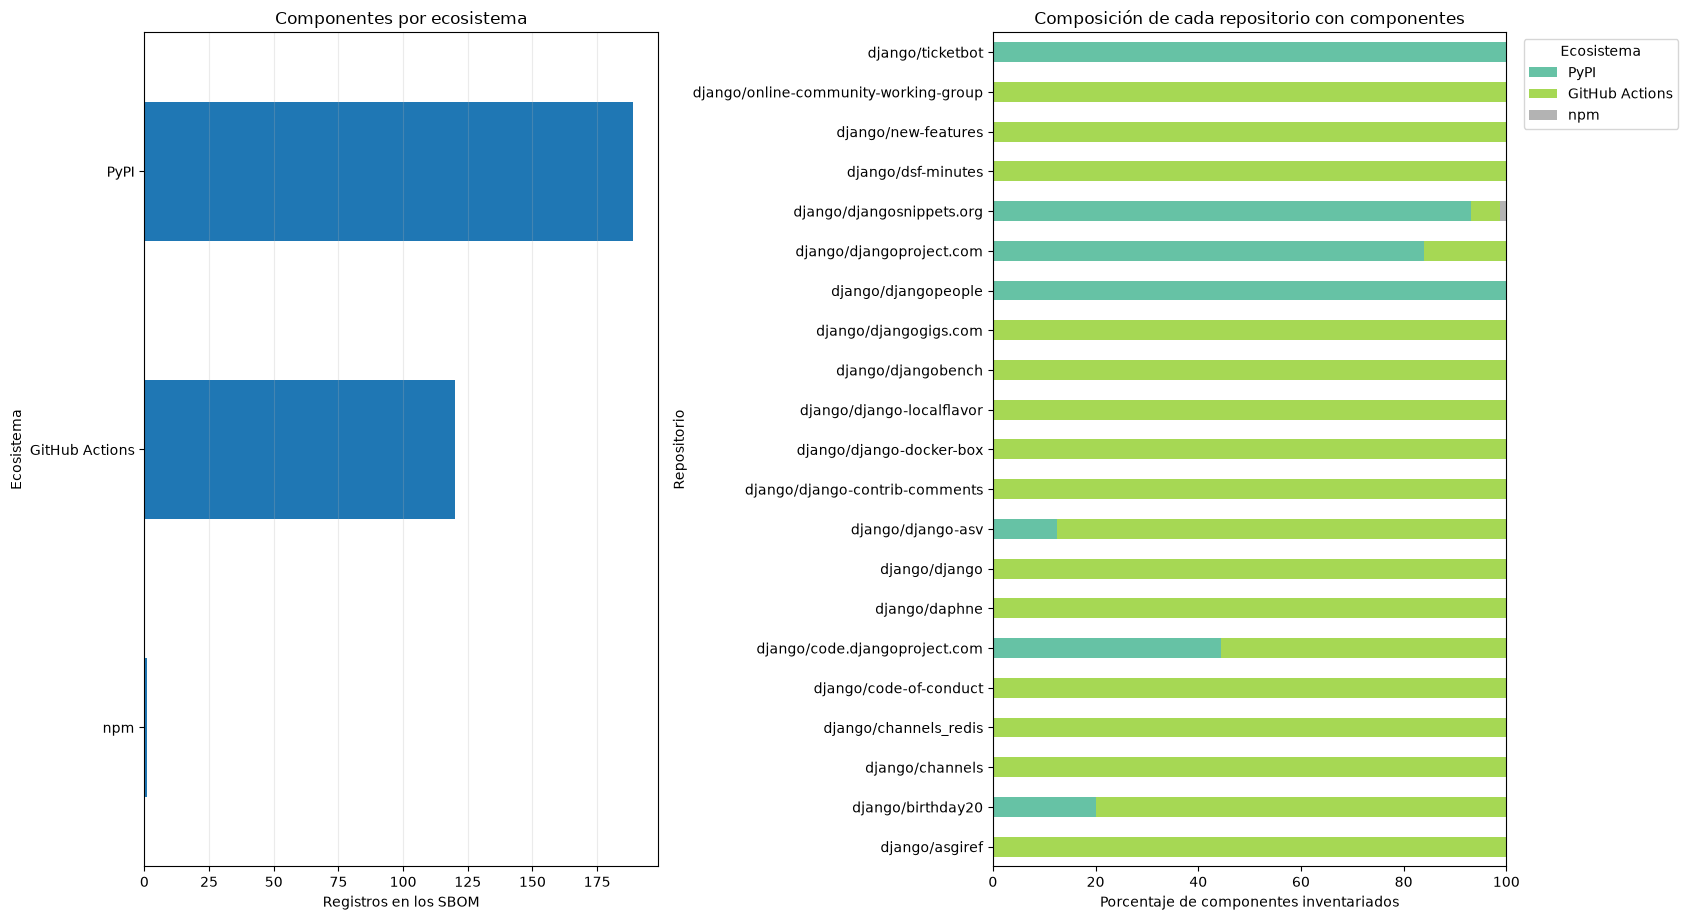

In [31]:
if componentes_sbom.empty:
    print('No hay componentes en los SBOM válidos cargados; consultar la cobertura.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(17, max(6, len(matriz_ecosistemas) * 0.3)))
    resumen_ecosistemas.set_index('ecosistema')['componentes'].sort_values().plot.barh(ax=axes[0])
    axes[0].set_title('Componentes por ecosistema')
    axes[0].set_xlabel('Registros en los SBOM')
    axes[0].set_ylabel('Ecosistema')
    axes[0].grid(axis='x', alpha=0.25)

    repositorios_con_componentes = matriz_ecosistemas.sum(axis=1) > 0
    (proporciones_ecosistemas.loc[repositorios_con_componentes] * 100).plot.barh(
        stacked=True, ax=axes[1], colormap='Set2',
    )
    axes[1].set_title('Composición de cada repositorio con componentes')
    axes[1].set_xlabel('Porcentaje de componentes inventariados')
    axes[1].set_ylabel('Repositorio')
    axes[1].set_xlim(0, 100)
    axes[1].legend(title='Ecosistema', loc='upper left', bbox_to_anchor=(1.02, 1))
    fig.tight_layout()
    plt.show()


### Interpretación


In [32]:
observaciones_sbom = [
    f'- Se cargaron **{len(repositorios_sbom_validos)} SBOM válidos** '
    f'de **{len(repositories)} repositorios**, con **{len(componentes_sbom)} registros de componentes**.',
    f'- **{int(cobertura_sbom["sbom_vacio"].eq(True).sum())} SBOM válidos** no contienen componentes.',
    f'- **{int(cobertura_sbom["sbom_status"].ne("generated").sum())} repositorios** '
    'no tienen un inventario válido cargado; consultar su estado en la cobertura.',
]
for row in resumen_ecosistemas.itertuples():
    observaciones_sbom.append(
        f'- **{row.ecosistema}**: {row.componentes} componentes '
        f'({row.proporcion_componentes:.1%}), presentes en {row.repositorios} repositorios.'
    )
if not resumen_ecosistemas.empty:
    principal = resumen_ecosistemas.iloc[0]
    observaciones_sbom.append(
        f'\n**{principal["ecosistema"]}** tiene la mayor cantidad de registros en el inventario. '
        'El gráfico por repositorio permite comprobar si esa composición se repite '
        'entre proyectos o está concentrada en algunos de ellos.'
    )
display(Markdown('\n'.join(observaciones_sbom)))


- Se cargaron **31 SBOM válidos** de **31 repositorios**, con **310 registros de componentes**.
- **10 SBOM válidos** no contienen componentes.
- **0 repositorios** no tienen un inventario válido cargado; consultar su estado en la cobertura.
- **PyPI**: 189 componentes (61.0%), presentes en 7 repositorios.
- **GitHub Actions**: 120 componentes (38.7%), presentes en 19 repositorios.
- **npm**: 1 componentes (0.3%), presentes en 1 repositorios.

**PyPI** tiene la mayor cantidad de registros en el inventario. El gráfico por repositorio permite comprobar si esa composición se repite entre proyectos o está concentrada en algunos de ellos.

### Limitaciones

La distribución describe lo que Syft inventarió en esta ejecución. Un inventario vacío no demuestra que el proyecto carezca de dependencias; el resultado depende de los archivos presentes y de los catalogadores utilizados.

Se incluyen componentes de desarrollo, pruebas y automatización. GitHub Actions describe un ecosistema de automatización, no un lenguaje de programación; tampoco se deduce el lenguaje principal del repositorio a partir de sus componentes. Los conteos no distinguen dependencias directas de transitivas y pueden incluir varias versiones o apariciones de un mismo paquete.

La presencia de un componente no implica una vulnerabilidad ni demuestra uso durante la ejecución. Los porcentajes por repositorio ponderan todos sus registros por igual y los porcentajes globales dan más peso a los inventarios grandes. Las preguntas sobre componentes vulnerables y paquetes compartidos se estudian por separado.


## Pregunta 8. ¿Qué repositorios tienen más componentes y qué proporción presenta coincidencias con vulnerabilidades conocidas?

### Método

Se cruzan los componentes cargados en la pregunta 7 con los hallazgos de Grype del dataset de la misma ejecución. La clave de correspondencia contiene **repositorio, ecosistema, nombre y versión**. Para PyPI se comparan los nombres en minúsculas y se sustituyen secuencias de guiones, puntos y guiones bajos por un guion. En los demás ecosistemas se conserva el nombre; las versiones se comparan como texto exacto, sin inferir equivalencias entre versiones ni resolver etiquetas a commits.

Se mantiene la unidad de la pregunta 7: registros de componentes del SBOM. Cada registro se marca una sola vez como afectado si su clave tiene al menos una coincidencia de Grype, independientemente del número de identificadores asociados. Si la misma identidad aparece en varios registros del SBOM, cada registro contribuye al inventario y al numerador; por eso también se informa el número de identidades distintas afectadas.

**Proporción afectada = registros de componentes con coincidencias / registros de componentes inventariados.** Los identificadores distintos por componente se conservan como detalle, pero no se suman para calcular esa proporción.

La proporción solo se presenta cuando el SBOM está disponible y es válido, Grype terminó como `analyzed`, todos los componentes tienen una clave utilizable y todos los hallazgos de Grype tienen correspondencia en el inventario. Si alguna condición falla, queda no definida. Un inventario vacío también tiene proporción no definida. Una proporción cero significa ausencia de coincidencias observadas bajo esas condiciones, no ausencia demostrada de vulnerabilidades.


In [33]:
import re


def clave_componente(repository, ecosystem, name, version):
    values = (repository, ecosystem, name, version)
    if any(not isinstance(value, str) or not value.strip() for value in values):
        return None
    if ecosystem == 'Sin clasificar':
        return None
    name = name.strip()
    if ecosystem == 'PyPI':
        name = re.sub(r'[-_.]+', '-', name).lower()
    return (repository, ecosystem, name, version.strip())


def ecosistema_grype(package_type):
    if not isinstance(package_type, str) or not package_type.strip():
        return 'Sin clasificar'
    package_type = package_type.strip().lower()
    return {
        'python': 'PyPI', 'pypi': 'PyPI', 'npm': 'npm',
        'github-action': 'GitHub Actions', 'github-action-workflow': 'GitHub Actions',
    }.get(package_type, f'Syft: {package_type}')


def comparar_componentes_grype(components, sbom_coverage, all_findings, repo_table):
    detail = components.copy()
    detail['clave'] = pd.Series([
        clave_componente(row.repository, row.ecosistema, row.name, row.version)
        for row in detail.itertuples()
    ], index=detail.index, dtype=object)
    grype = all_findings.loc[all_findings['tool'] == 'grype'].copy()
    grype['clave'] = pd.Series([
        clave_componente(row.repository, ecosistema_grype(row.package_type), row.package, row.version)
        for row in grype.itertuples()
    ], index=grype.index, dtype=object)

    known_keys = set(detail['clave'].dropna())
    grype['tiene_correspondencia'] = grype['clave'].map(
        lambda key: key is not None and key in known_keys
    )
    unmatched = grype.loc[~grype['tiene_correspondencia']].copy()
    matched = grype.loc[grype['tiene_correspondencia']]
    ids_by_key = matched.groupby('clave')['vulnerability_id'].agg(
        lambda values: sorted(set(values.dropna()))
    ).to_dict()
    detail['identificadores_grype'] = detail['clave'].map(lambda key: ids_by_key.get(key, []))
    detail['identificadores_distintos'] = detail['identificadores_grype'].map(len)
    detail['con_coincidencias'] = detail['identificadores_distintos'] > 0
    detail['clave_disponible'] = detail['clave'].notna()

    component_metrics = detail.groupby('repository').agg(
        componentes_identificables=('clave_disponible', 'sum'),
        componentes_con_coincidencias=('con_coincidencias', 'sum'),
    )
    affected_identities = (
        detail.loc[detail['con_coincidencias']]
        .groupby('repository')['clave'].nunique().rename('identidades_afectadas')
    )
    summary = (
        sbom_coverage[['repository', 'sbom_status', 'componentes_cargados']]
        .rename(columns={'componentes_cargados': 'componentes_totales'})
        .merge(repo_table[['repository', 'grype_status']], on='repository', validate='one_to_one')
        .merge(component_metrics, on='repository', how='left', validate='one_to_one')
        .merge(affected_identities, on='repository', how='left', validate='one_to_one')
        .merge(grype.groupby('repository').size().rename('hallazgos_grype'),
               on='repository', how='left', validate='one_to_one')
        .merge(unmatched.groupby('repository').size().rename('hallazgos_sin_correspondencia'),
               on='repository', how='left', validate='one_to_one')
    )
    metrics = ['componentes_identificables', 'componentes_con_coincidencias', 'identidades_afectadas']
    valid_inventory = summary['sbom_status'].eq('generated')
    summary[metrics] = summary[metrics].fillna(0)
    summary.loc[~valid_inventory, metrics] = float('nan')
    for column in ['hallazgos_grype', 'hallazgos_sin_correspondencia']:
        summary[column] = summary[column].fillna(0).astype(int)
    summary['componentes_sin_clave'] = summary['componentes_totales'] - summary['componentes_identificables']
    summary['cobertura_identificacion'] = (
        summary['componentes_identificables'] / summary['componentes_totales'].replace(0, float('nan'))
    )
    summary['comparacion_completa'] = (
        valid_inventory & summary['grype_status'].eq('analyzed')
        & summary['componentes_sin_clave'].eq(0)
        & summary['hallazgos_sin_correspondencia'].eq(0)
    )
    summary['proporcion_afectada'] = (
        summary['componentes_con_coincidencias']
        / summary['componentes_totales'].replace(0, float('nan'))
    ).where(summary['comparacion_completa'])
    summary = summary.sort_values(
        ['componentes_totales', 'repository'], ascending=[False, True], na_position='last',
    ).reset_index(drop=True)
    return summary, detail, unmatched


resumen_componentes, detalle_componentes, grype_sin_correspondencia = comparar_componentes_grype(
    componentes_sbom, cobertura_sbom, findings, repositories,
)


### Resultados

La tabla principal ordena los repositorios por tamaño de inventario. Incluye el estado de ambas herramientas, la cobertura de identificación, las coincidencias sin correspondencia y la proporción afectada cuando se puede calcular. El detalle permite revisar qué componentes e identificadores producen el numerador.


In [34]:
display(resumen_componentes.round(3))
display(detalle_componentes.loc[
    detalle_componentes['con_coincidencias'],
    ['repository', 'component_index', 'ecosistema', 'name', 'version',
     'identificadores_distintos', 'identificadores_grype'],
].sort_values(['repository', 'ecosistema', 'name', 'version']))
if not grype_sin_correspondencia.empty:
    display(grype_sin_correspondencia[
        ['repository', 'package_type', 'package', 'version', 'vulnerability_id']
    ])
else:
    print('Todos los registros de Grype tienen correspondencia con el inventario cargado.')


,repository,sbom_status,componentes_totales,grype_status,componentes_identificables,componentes_con_coincidencias,identidades_afectadas,hallazgos_grype,hallazgos_sin_correspondencia,componentes_sin_clave,cobertura_identificacion,comparacion_completa,proporcion_afectada
0,django/djangoproject.com,generated,87,analyzed,87.0,2.0,2.0,4,0,0.0,1.0,True,0.023
1,django/djangosnippets.org,generated,86,analyzed,86.0,20.0,20.0,91,0,0.0,1.0,True,0.233
2,django/django,generated,40,analyzed,40.0,1.0,1.0,1,0,0.0,1.0,True,0.025
3,django/djangopeople,generated,23,analyzed,23.0,7.0,7.0,32,0,0.0,1.0,True,0.304
4,django/code.djangoproject.com,generated,18,analyzed,18.0,2.0,2.0,2,0,0.0,1.0,True,0.111
5,django/birthday20,generated,10,analyzed,10.0,0.0,0.0,0,0,0.0,1.0,True,0.000
6,django/django-asv,generated,8,analyzed,8.0,0.0,0.0,0,0,0.0,1.0,True,0.000
7,django/djangogigs.com,generated,5,analyzed,5.0,0.0,0.0,0,0,0.0,1.0,True,0.000
8,django/dsf-minutes,generated,5,analyzed,5.0,0.0,0.0,0,0,0.0,1.0,True,0.000
9,django/channels,generated,4,analyzed,4.0,0.0,0.0,0,0,0.0,1.0,True,0.000


,repository,component_index,ecosistema,name,version,identificadores_distintos,identificadores_grype
34,django/code.djangoproject.com,14,GitHub Actions,psf/black,25.9.0,1,[GHSA-v53h-f6m7-xcgm]
32,django/code.djangoproject.com,12,PyPI,multipart,1.1.0,1,[GHSA-p2m9-wcp5-6qw3]
78,django/django,38,GitHub Actions,psf/black,stable,1,[GHSA-v53h-f6m7-xcgm]
103,django/djangopeople,2,PyPI,django,2.1.10,22,"[GHSA-3h9f-r86x-qvjx, GHSA-68w8-qjq3-2gfm, GHS..."
105,django/djangopeople,4,PyPI,django-debug-toolbar,1.10.1,1,[GHSA-pghf-347x-c2gj]
109,django/djangopeople,8,PyPI,django-ses,0.8.10,1,[GHSA-qg36-9jxh-fj25]
113,django/djangopeople,12,PyPI,geopy,1.18.1,1,[GHSA-mhvh-fq92-pfmr]
114,django/djangopeople,13,PyPI,gevent,1.4.0,1,[GHSA-x7m3-jprg-wc5g]
116,django/djangopeople,15,PyPI,gunicorn,19.9.0,2,"[GHSA-hc5x-x2vx-497g, GHSA-w3h3-4rj7-4ph4]"
122,django/djangopeople,21,PyPI,requests,2.22.0,4,"[GHSA-9hjg-9r4m-mvj7, GHSA-9wx4-h78v-vm56, GHS..."


Todos los registros de Grype tienen correspondencia con el inventario cargado.


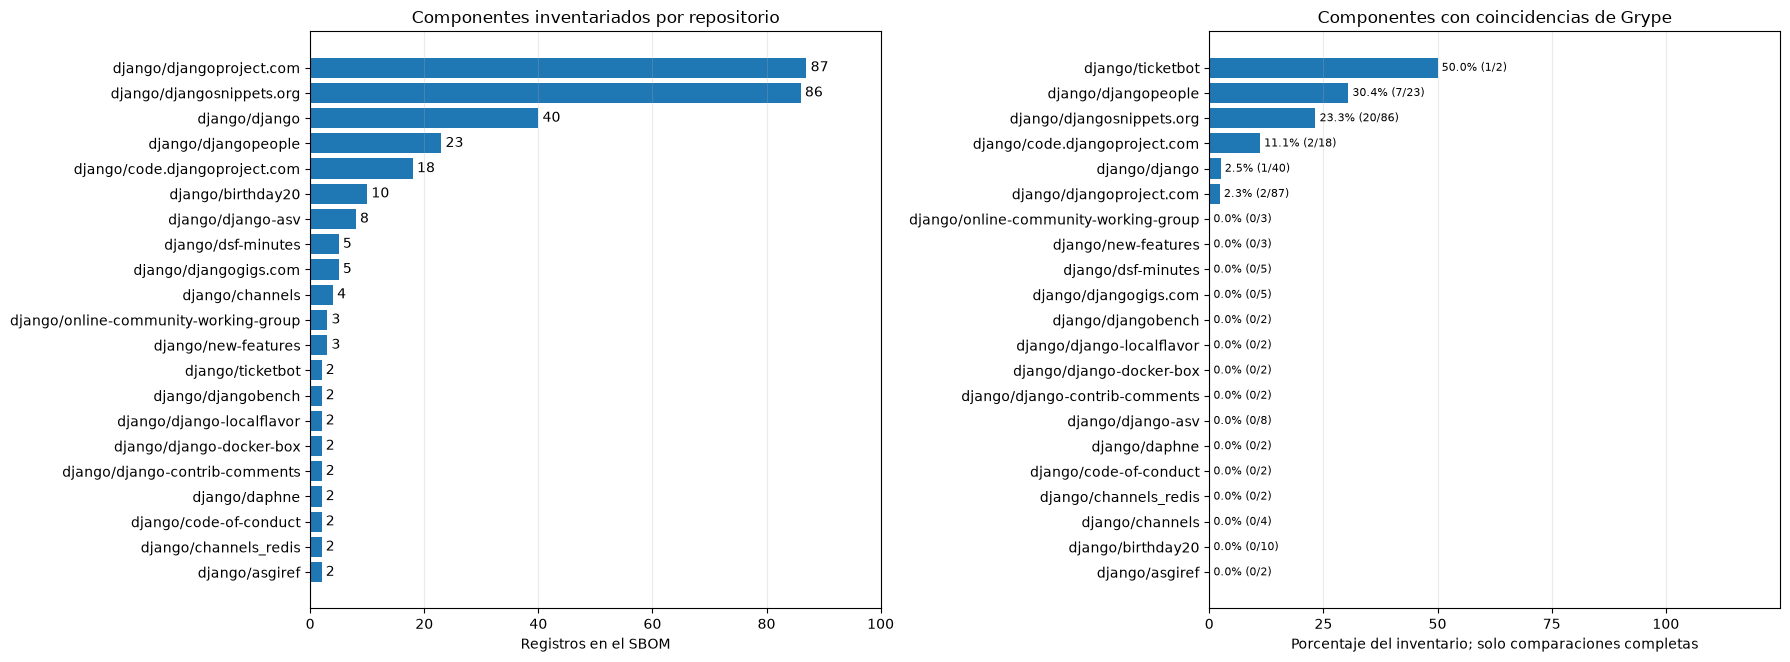

In [35]:
inventarios_grafico = resumen_componentes.loc[
    resumen_componentes['componentes_totales'].gt(0)
].sort_values(['componentes_totales', 'repository'])
proporciones_grafico = resumen_componentes.loc[
    resumen_componentes['proporcion_afectada'].notna()
].sort_values(['proporcion_afectada', 'repository'])

if inventarios_grafico.empty:
    print('No hay inventarios con componentes disponibles para comparar.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(inventarios_grafico) * 0.32)))
    bars = axes[0].barh(inventarios_grafico['repository'], inventarios_grafico['componentes_totales'])
    axes[0].bar_label(bars, fmt='%.0f', padding=3)
    axes[0].set_xlim(0, inventarios_grafico['componentes_totales'].max() * 1.15)
    axes[0].set_title('Componentes inventariados por repositorio')
    axes[0].set_xlabel('Registros en el SBOM')
    axes[0].grid(axis='x', alpha=0.25)
    if proporciones_grafico.empty:
        axes[1].text(0.5, 0.5, 'No hay proporciones con cobertura completa',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()
    else:
        bars = axes[1].barh(proporciones_grafico['repository'], proporciones_grafico['proporcion_afectada'] * 100)
        axes[1].bar_label(bars, labels=[
            f'{row.proporcion_afectada:.1%} ({int(row.componentes_con_coincidencias)}/{int(row.componentes_totales)})'
            for row in proporciones_grafico.itertuples()
        ], padding=3, fontsize=8)
        axes[1].set_xlim(0, 125)
        axes[1].set_xticks([0, 25, 50, 75, 100])
        axes[1].set_title('Componentes con coincidencias de Grype')
        axes[1].set_xlabel('Porcentaje del inventario; solo comparaciones completas')
        axes[1].grid(axis='x', alpha=0.25)
    fig.tight_layout()
    plt.show()


### Interpretación


In [36]:
observaciones_componentes = []
inventarios_disponibles = resumen_componentes.loc[resumen_componentes['componentes_totales'].notna()]
proporciones_disponibles = resumen_componentes.loc[resumen_componentes['proporcion_afectada'].notna()]
if not inventarios_disponibles.empty:
    largest = inventarios_disponibles.iloc[0]
    observaciones_componentes.append(
        f'- **{largest["repository"]}** encabeza el inventario con '
        f'**{int(largest["componentes_totales"])} componentes** '
        '(en caso de empate, se muestra el primero por nombre).'
    )
if not proporciones_disponibles.empty:
    highest = proporciones_disponibles.sort_values(
        ['proporcion_afectada', 'componentes_con_coincidencias', 'repository'],
        ascending=[False, False, True],
    ).iloc[0]
    observaciones_componentes.append(
        f'- La mayor proporción observada corresponde a **{highest["repository"]}**: '
        f'**{int(highest["componentes_con_coincidencias"])}/{int(highest["componentes_totales"])}** '
        f'componentes con coincidencias (**{highest["proporcion_afectada"]:.1%}**). '
        'Los empates se ordenan por cantidad afectada y luego por nombre.'
    )
observaciones_componentes.extend([
    f'- **{len(proporciones_disponibles)} repositorios** tienen una proporción calculable; '
    f'**{int(resumen_componentes["componentes_totales"].eq(0).sum())}** tienen inventarios vacíos.',
    f'- **{int((~resumen_componentes["comparacion_completa"]).sum())} repositorios** '
    'no cumplen todas las condiciones de cobertura y correspondencia.',
    f'- Hay **{len(grype_sin_correspondencia)} registros de Grype** sin correspondencia en el inventario.',
])
display(Markdown('\n'.join(observaciones_componentes)))


- **django/djangoproject.com** encabeza el inventario con **87 componentes** (en caso de empate, se muestra el primero por nombre).
- La mayor proporción observada corresponde a **django/ticketbot**: **1/2** componentes con coincidencias (**50.0%**). Los empates se ordenan por cantidad afectada y luego por nombre.
- **21 repositorios** tienen una proporción calculable; **10** tienen inventarios vacíos.
- **0 repositorios** no cumplen todas las condiciones de cobertura y correspondencia.
- Hay **0 registros de Grype** sin correspondencia en el inventario.

### Limitaciones

Una coincidencia indica que Grype relaciona un componente con una vulnerabilidad conocida; no confirma que sea explotable en ese repositorio. La proporción no pondera severidad, uso en producción ni alcance durante la ejecución. Un porcentaje elevado sobre pocos componentes debe leerse junto con su numerador y denominador.

La comparación depende de la completitud del SBOM, la cobertura de Grype por ecosistema y la base de vulnerabilidades utilizada. El estado `analyzed` indica que la herramienta terminó, no que cubra todas las vulnerabilidades posibles. Se incluyen dependencias de pruebas, desarrollo y automatización.

La correspondencia por nombre, ecosistema y versión puede asociar varios registros del inventario a una misma identidad. No se infieren equivalencias para versiones textualmente distintas ni se resuelven alias CVE/GHSA; los identificadores asociados se muestran tal como aparecen en la evidencia. Al cambiar de ejecución deben seleccionarse reportes compatibles con la misma revisión del código.


## Pregunta 9. ¿Qué componentes y versiones se comparten entre repositorios, tengan o no hallazgos?

### Método

Se utiliza el inventario completo de la pregunta 7. Se distinguen dos niveles: **paquete compartido**, identificado por ecosistema y nombre normalizado, y **versión compartida**, que añade la versión textual exacta. En ambos casos deben aparecer en al menos dos repositorios distintos. Varias apariciones dentro de un único repositorio no convierten un paquete en compartido.

Se reutiliza la normalización de nombres de PyPI de la pregunta 8. Los registros sin nombre o ecosistema identificable se excluyen de las agrupaciones; los que carecen de versión pueden contribuir a un paquete compartido, pero no a una versión compartida. No se eliminan versiones ni se resuelven tags de GitHub a SHA.

Se muestran repositorios, versiones observadas y registros de inventario. La columna `alguna_coincidencia_grype` solo indica si alguna aparición tiene coincidencias observadas; no filtra el inventario ni convierte su ausencia en garantía de seguridad. La cobertura de SBOM y Grype se conserva en las preguntas 7 y 8.


In [37]:
def resumir_componentes_compartidos(component_detail):
    inventory = component_detail.copy()
    name_keys = [
        clave_componente(row.repository, row.ecosistema, row.name, 'nombre_sin_version')
        for row in inventory.itertuples()
    ]
    inventory['nombre_normalizado'] = [key[2] if key else None for key in name_keys]
    inventory['version_identificada'] = inventory['version'].map(
        lambda value: value.strip() if isinstance(value, str) and value.strip() else None
    )
    usable = inventory.dropna(subset=['nombre_normalizado']).copy()
    group_columns = ['ecosistema', 'nombre_normalizado']
    packages = usable.groupby(group_columns).agg(
        repositorios=('repository', 'nunique'), registros=('repository', 'size'),
        lista_repositorios=('repository', lambda values: sorted(set(values))),
        versiones_observadas=('version_identificada', lambda values: sorted(set(values.dropna()))),
        alguna_coincidencia_grype=('con_coincidencias', 'any'),
    ).reset_index()
    packages = packages.loc[packages['repositorios'] >= 2].sort_values(
        ['repositorios', 'registros', 'ecosistema', 'nombre_normalizado'],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    versions = usable.dropna(subset=['version_identificada']).groupby(
        group_columns + ['version_identificada']
    ).agg(
        repositorios=('repository', 'nunique'), registros=('repository', 'size'),
        lista_repositorios=('repository', lambda values: sorted(set(values))),
        alguna_coincidencia_grype=('con_coincidencias', 'any'),
    ).reset_index()
    versions = versions.loc[versions['repositorios'] >= 2].sort_values(
        ['repositorios', 'registros', 'ecosistema', 'nombre_normalizado', 'version_identificada'],
        ascending=[False, False, True, True, True],
    ).reset_index(drop=True)
    shared_detail = usable.merge(
        packages[group_columns], on=group_columns, how='inner', validate='many_to_one',
    )
    exclusions = {
        'sin_identidad_paquete': int(inventory['nombre_normalizado'].isna().sum()),
        'identificables_sin_version': int(usable['version_identificada'].isna().sum()),
    }
    return packages, versions, shared_detail, exclusions


paquetes_sbom_compartidos, versiones_sbom_compartidas, detalle_compartidos_sbom, exclusiones_compartidos = (
    resumir_componentes_compartidos(detalle_componentes)
)
display(paquetes_sbom_compartidos)
display(versiones_sbom_compartidas)
display(detalle_compartidos_sbom[
    ['repository', 'ecosistema', 'nombre_normalizado', 'version_identificada', 'purl', 'con_coincidencias']
].sort_values(['ecosistema', 'nombre_normalizado', 'repository', 'version_identificada']))
print('Registros excluidos o sin versión:', exclusiones_compartidos)


,ecosistema,nombre_normalizado,repositorios,registros,lista_repositorios,versiones_observadas,alguna_coincidencia_grype
0,GitHub Actions,actions/checkout,19,42,"[django/asgiref, django/birthday20, django/cha...","[de0fac2e4500dabe0009e67214ff5f5447ce83dd, v2,...",False
1,GitHub Actions,actions/setup-python,13,24,"[django/asgiref, django/channels, django/chann...","[a309ff8b426b58ec0e2a45f0f869d46889d02405, v3,...",False
2,GitHub Actions,actions/github-script,4,6,"[django/code-of-conduct, django/django, django...","[v7, v9]",False
3,PyPI,django,4,4,"[django/code.djangoproject.com, django/djangop...","[2.1.10, 5.2.17, 5.2.7, 6.1]",True
4,PyPI,gunicorn,4,4,"[django/code.djangoproject.com, django/djangop...","[19.9.0, 20.1.0, 23.0.0, 26.0.0]",True
5,PyPI,requests,4,4,"[django/djangopeople, django/djangoproject.com...","[2.22.0, 2.31.0, 2.32.4, 2.34.2]",True
6,GitHub Actions,actions/cache,3,4,"[django/birthday20, django/django, django/djan...","[v3, v4, v6]",False
7,GitHub Actions,actions/configure-pages,3,3,"[django/birthday20, django/djangogigs.com, dja...","[v4, v5]",False
8,GitHub Actions,actions/deploy-pages,3,3,"[django/birthday20, django/djangogigs.com, dja...",[v4],False
9,GitHub Actions,actions/upload-pages-artifact,3,3,"[django/birthday20, django/djangogigs.com, dja...",[v3],False


,ecosistema,nombre_normalizado,version_identificada,repositorios,registros,lista_repositorios,alguna_coincidencia_grype
0,GitHub Actions,actions/checkout,v7,5,17,"[django/asgiref, django/channels, django/chann...",False
1,GitHub Actions,actions/setup-python,v7,5,6,"[django/asgiref, django/channels, django/chann...",False
2,GitHub Actions,actions/checkout,v4,4,7,"[django/birthday20, django/code.djangoproject....",False
3,GitHub Actions,actions/setup-python,v6,3,12,"[django/django, django/django-localflavor, dja...",False
4,GitHub Actions,actions/checkout,v3,3,4,"[django/django-asv, django/django-contrib-comm...",False
5,GitHub Actions,actions/checkout,v6,3,4,"[django/code-of-conduct, django/django-localfl...",False
6,GitHub Actions,actions/checkout,v2,3,3,"[django/code.djangoproject.com, django/new-fea...",False
7,GitHub Actions,actions/deploy-pages,v4,3,3,"[django/birthday20, django/djangogigs.com, dja...",False
8,GitHub Actions,actions/github-script,v7,3,3,"[django/code-of-conduct, django/new-features, ...",False
9,GitHub Actions,actions/upload-pages-artifact,v3,3,3,"[django/birthday20, django/djangogigs.com, dja...",False


,repository,ecosistema,nombre_normalizado,version_identificada,purl,con_coincidencias
2,django/birthday20,GitHub Actions,actions/cache,v4,pkg:github/actions/cache@v4,False
33,django/django,GitHub Actions,actions/cache,v6,pkg:github/actions/cache@v6,False
34,django/django,GitHub Actions,actions/cache,v6,pkg:github/actions/cache@v6,False
64,django/django-asv,GitHub Actions,actions/cache,v3,pkg:github/actions/cache@v3,False
0,django/asgiref,GitHub Actions,actions/checkout,v7,pkg:github/actions/checkout@v7,False
...,...,...,...,...,...,...
161,django/djangosnippets.org,PyPI,tzdata,2025.2,pkg:pypi/tzdata@2025.2,False
129,django/djangoproject.com,PyPI,urllib3,2.7.0,pkg:pypi/urllib3@2.7.0,True
162,django/djangosnippets.org,PyPI,urllib3,2.5.0,pkg:pypi/urllib3@2.5.0,True
130,django/djangoproject.com,PyPI,watchdog,6.0.0,pkg:pypi/watchdog@6.0.0,False


Registros excluidos o sin versión: {'sin_identidad_paquete': 0, 'identificables_sin_version': 0}


### Resultados

Los gráficos ordenan por número de repositorios distintos. El primer panel permite compartir un paquete con versiones diferentes; el segundo exige la misma versión textual. Las tablas conservan todas las agrupaciones y los gráficos muestran hasta quince.


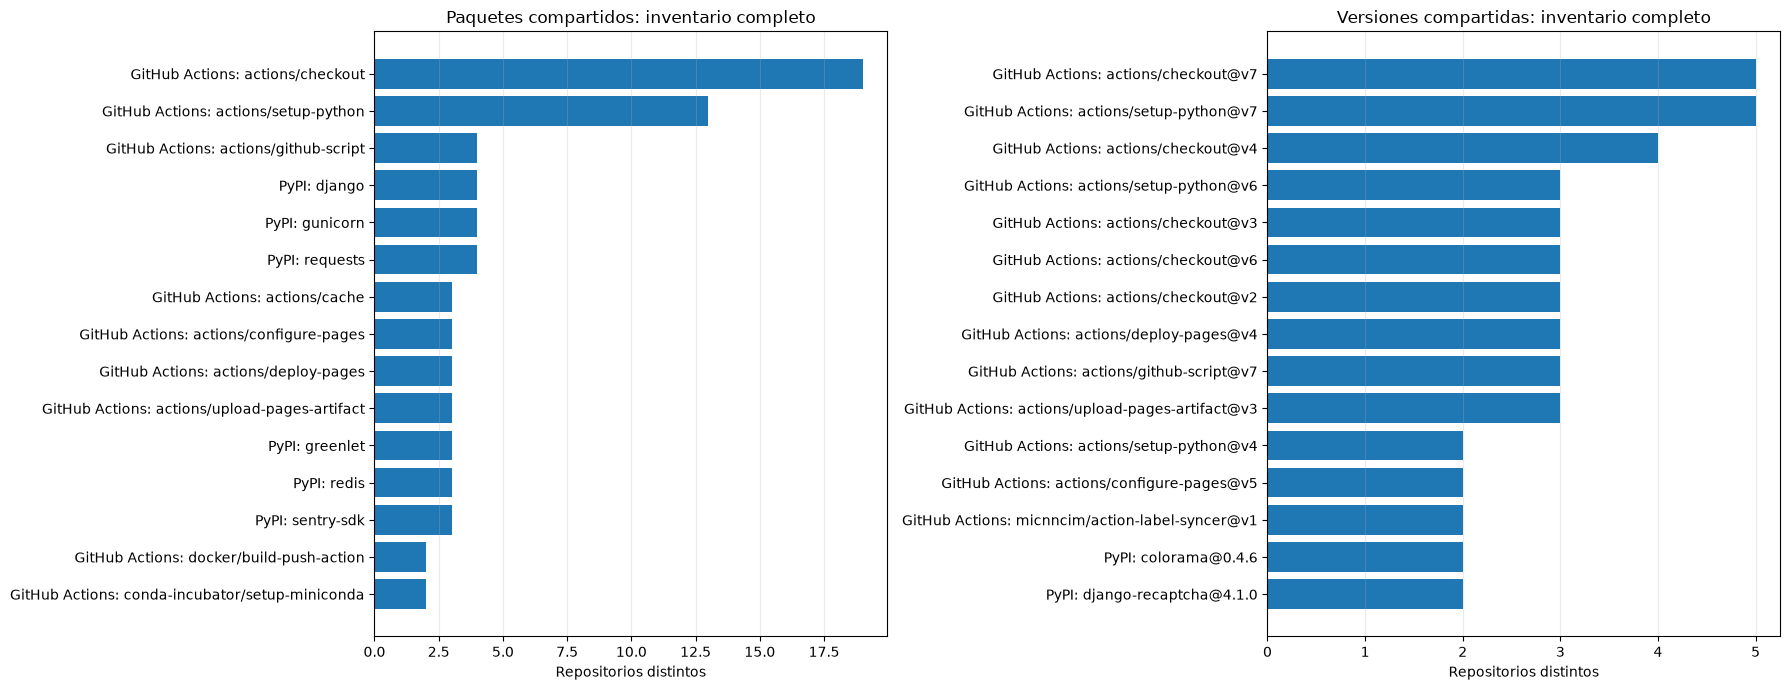

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for axis, frame, title, include_version in [
    (axes[0], paquetes_sbom_compartidos, 'Paquetes compartidos: inventario completo', False),
    (axes[1], versiones_sbom_compartidas, 'Versiones compartidas: inventario completo', True),
]:
    top = frame.head(15).iloc[::-1]
    labels = top['ecosistema'] + ': ' + top['nombre_normalizado']
    if include_version:
        labels = labels + '@' + top['version_identificada']
    axis.barh(labels, top['repositorios'])
    axis.set_title(title)
    axis.set_xlabel('Repositorios distintos')
    axis.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()


### Interpretación


In [39]:
observaciones_compartidos = [
    f'- **{len(paquetes_sbom_compartidos)} paquetes** aparecen en al menos dos repositorios.',
    f'- **{len(versiones_sbom_compartidas)} combinaciones de paquete y versión** '
    'aparecen en al menos dos repositorios.',
    f'- **{int((~paquetes_sbom_compartidos["alguna_coincidencia_grype"]).sum())} paquetes compartidos** '
    'no tienen coincidencias de Grype observadas en este cruce; siguen incluidos en el inventario.',
]
if not paquetes_sbom_compartidos.empty:
    leader = paquetes_sbom_compartidos.iloc[0]
    observaciones_compartidos.append(
        f'- **{leader["nombre_normalizado"]} ({leader["ecosistema"]})** tiene la mayor '
        f'presencia: **{leader["repositorios"]} repositorios** y '
        f'{len(leader["versiones_observadas"])} versiones textuales observadas.'
    )
display(Markdown('\n'.join(observaciones_compartidos)))


- **46 paquetes** aparecen en al menos dos repositorios.
- **20 combinaciones de paquete y versión** aparecen en al menos dos repositorios.
- **33 paquetes compartidos** no tienen coincidencias de Grype observadas en este cruce; siguen incluidos en el inventario.
- **actions/checkout (GitHub Actions)** tiene la mayor presencia: **19 repositorios** y 8 versiones textuales observadas.

### Limitaciones

La coincidencia de nombre y versión no demuestra que dos repositorios utilicen el mismo artefacto binario, configuración o contexto de ejecución. Tags como `main` o `stable` pueden representar revisiones distintas y no se resuelven en este análisis. Las PURL originales se conservan como detalle, pero la comparación no utiliza sus qualifiers ni subrutas.

La ausencia de coincidencias de Grype no prueba ausencia de vulnerabilidades. Los componentes de desarrollo y automatización también forman parte del inventario. Los SBOM ausentes o incompletos limitan el número de repositorios en los que se puede observar una dependencia compartida.


## Pregunta 10. ¿Qué problemas de seguridad se repiten en los workflows de CI y qué cobertura tiene su análisis?

### Método

Se carga el reporte de CodeQL señalado por `source_reports.codeql` del dataset, dentro de la copia local. La cobertura de CI requiere un resultado explícito del lenguaje **`actions`** por repositorio. Un análisis correcto de Python, JavaScript o Ruby no acredita análisis de workflows.

Se conservan el estado general de CodeQL y el estado específico de Actions. Sin resultado de ese lenguaje, se informa `not_reported`, con conteo no definido. Los hallazgos de resultados parciales o fallidos se mantienen visibles como observados, pero solo `analyzed` acredita una ejecución completa para ese lenguaje.

Cuando existe evidencia, se presentan reglas de CI por frecuencia y número de repositorios, niveles SARIF y archivos asociados. Se usa la lista de hallazgos por lenguaje una sola vez, sin volver a sumar el agregado del repositorio. La presencia de componentes GitHub Actions en el SBOM describe inventario y no sustituye esta evidencia de análisis.


In [40]:
def analizar_cobertura_ci(report, repo_table):
    if not isinstance(report, dict) or not isinstance(report.get('repositories'), list):
        raise ValueError('El reporte CodeQL no contiene una lista de repositorios.')
    records = report['repositories']
    known = set(repo_table['repository'])
    seen, coverage_rows, finding_rows = set(), [], []
    for record in records:
        name = record.get('name')
        if name not in known or name in seen:
            raise ValueError(f'Repositorio desconocido o repetido en CodeQL: {name}')
        seen.add(name)
        actions = [item for item in record.get('languages', []) if item.get('language') == 'actions']
        if len(actions) > 1:
            raise ValueError(f'Resultado Actions duplicado: {name}')
        language_result = actions[0] if actions else None
        language_findings = language_result.get('findings', []) if language_result else []
        coverage_rows.append({
            'repository': name, 'codeql_status': record.get('status'),
            'actions_status': language_result.get('status') if language_result else 'not_reported',
            'hallazgos_ci_observados': len(language_findings) if language_result else None,
            'error_ci': language_result.get('error') if language_result else None,
        })
        for finding in language_findings:
            finding_rows.append({
                'repository': name, 'rule_id': finding.get('rule_id'),
                'sarif_level': finding.get('severity'), 'file': finding.get('file'),
                'message': finding.get('message'), 'actions_status': language_result.get('status'),
            })
    for name in sorted(known - seen):
        coverage_rows.append({
            'repository': name, 'codeql_status': 'not_reported', 'actions_status': 'not_reported',
            'hallazgos_ci_observados': None, 'error_ci': 'Repositorio ausente del reporte CodeQL.',
        })
    return (
        pd.DataFrame(coverage_rows, columns=[
            'repository', 'codeql_status', 'actions_status', 'hallazgos_ci_observados', 'error_ci',
        ]).sort_values('repository').reset_index(drop=True),
        pd.DataFrame(finding_rows, columns=[
            'repository', 'rule_id', 'sarif_level', 'file', 'message', 'actions_status',
        ]),
    )


codeql_report_relative = Path(dataset['source_reports']['codeql'].replace('\\', '/'))
CODEQL_REPORT_PATH = (EVIDENCE_ROOT / codeql_report_relative).resolve()
if not CODEQL_REPORT_PATH.is_relative_to(EVIDENCE_ROOT.resolve()):
    raise ValueError('El reporte CodeQL debe pertenecer a la copia local seleccionada.')
with CODEQL_REPORT_PATH.open(encoding='utf-8') as report_file:
    reporte_codeql_ci = json.load(report_file)
if reporte_codeql_ci.get('organization') != dataset['organization']:
    raise ValueError('El reporte CodeQL no corresponde a la organización del dataset.')
cobertura_ci, hallazgos_ci = analizar_cobertura_ci(reporte_codeql_ci, repositories)
reglas_ci = hallazgos_ci.groupby('rule_id').agg(
    coincidencias=('repository', 'size'), repositorios=('repository', 'nunique'),
    ejemplo_mensaje=('message', 'first'),
).reset_index().sort_values(['coincidencias', 'rule_id'], ascending=[False, True])
reglas_ci_compartidas = reglas_ci.loc[reglas_ci['repositorios'] >= 2]
severidades_ci = hallazgos_ci.assign(
    sarif_level=hallazgos_ci['sarif_level'].fillna('Sin dato')
).groupby('sarif_level').size().rename('hallazgos').reset_index()


### Resultados

La cobertura se muestra para todos los repositorios. Las tablas de reglas y niveles solo contienen evidencia explícita de Actions; pueden estar vacías por falta de análisis y no necesariamente por ausencia de alertas.


In [41]:
display(cobertura_ci)
display(cobertura_ci.groupby('actions_status').size().rename('repositorios').to_frame())
display(reglas_ci, reglas_ci_compartidas, severidades_ci)
if not hallazgos_ci.empty:
    display(hallazgos_ci.sort_values(['repository', 'rule_id', 'file']))


,repository,codeql_status,actions_status,hallazgos_ci_observados,error_ci
0,django/.github,database_failed,not_reported,None,None
1,django/accessibility,database_failed,not_reported,None,None
2,django/asgi_ipc,analyzed,not_reported,None,None
3,django/asgiref,analyzed,not_reported,None,None
4,django/birthday20,analyzed,not_reported,None,None
5,django/channels,analyzed,not_reported,None,None
6,django/channels_redis,analyzed,not_reported,None,None
7,django/code-of-conduct,database_failed,not_reported,None,None
8,django/code.djangoproject.com,analyzed,not_reported,None,None
9,django/daphne,analyzed,not_reported,None,None


,repositorios
actions_status,
not_reported,31


,rule_id,coincidencias,repositorios,ejemplo_mensaje


,rule_id,coincidencias,repositorios,ejemplo_mensaje


,sarif_level,hallazgos


### Interpretación


In [42]:
ci_completos = int(cobertura_ci['actions_status'].eq('analyzed').sum())
ci_sin_evidencia = int(cobertura_ci['actions_status'].eq('not_reported').sum())
if ci_sin_evidencia == len(cobertura_ci):
    interpretacion_ci = (
        f'**La pregunta de seguridad de CI no puede responderse con esta ejecución.** '
        f'Los {len(cobertura_ci)} repositorios carecen de un resultado explícito de Actions. '
        'Esto no significa que tengan cero problemas ni que carezcan de workflows. '
        'Se necesita una ejecución de análisis de Actions con estados y hallazgos por repositorio.'
    )
else:
    interpretacion_ci = (
        f'Hay **{ci_completos} repositorios** con análisis de Actions completo y '
        f'**{ci_sin_evidencia}** sin resultado de ese lenguaje. Se observaron '
        f'**{len(hallazgos_ci)} hallazgos**, **{len(reglas_ci)} reglas** y '
        f'**{len(reglas_ci_compartidas)} reglas compartidas**. '
        'Los estados parciales y fallidos deben revisarse antes de comparar repositorios.'
    )
display(Markdown(interpretacion_ci))


**La pregunta de seguridad de CI no puede responderse con esta ejecución.** Los 31 repositorios carecen de un resultado explícito de Actions. Esto no significa que tengan cero problemas ni que carezcan de workflows. Se necesita una ejecución de análisis de Actions con estados y hallazgos por repositorio.

### Limitaciones

Esta sección estudia GitHub Actions cuando existe evidencia explícita en el reporte de CodeQL; no cubre otros sistemas de CI. Un estado general `analyzed` no garantiza cobertura de Actions. Los niveles SARIF no son puntajes CVSS, y las alertas no confirman explotabilidad. Sin cobertura de Actions, no se elaboran rankings de seguridad ni conclusiones sobre ausencia de problemas.


## Resultados para el Visualizer
Exportar aquí, al desarrollar los análisis, las métricas y tablas derivadas junto con sus definiciones, filtros y observaciones. Mantener la evidencia original en el Miner.